# Chargeback Evidence Responder — Exploratory Data Analysis

**Razorpay AI Buildathon · Track 02 (AI Risk Manager)**

---

## What this notebook is for

Before we build a model, we need to answer a set of questions that determine *which* model to build and *how* to evaluate it honestly. This notebook is not a generic data-science walkthrough — it is a set of specific decisions we need to make, each with the evidence for that decision shown on screen.

### The business problem, in one paragraph

A merchant sells online. Weeks after a sale, the customer's bank claws the money back — the merchant is debited **first** and asked questions afterwards. The merchant then has one chance, within a deadline, to submit evidence proving the sale was legitimate. Two things make this hard: every type of claim requires a *different* kind of proof, and fighting costs money (a non-refundable contest fee), so blindly fighting everything is as wrong as blindly accepting everything.

**Our system decides: given this dispute, is it worth contesting — and if so, which evidence do we submit?**

### The questions this notebook must answer

| # | Question | Why it matters for the ML notebook |
|---|---|---|
| 1 | What does the data actually contain, and do the tables join cleanly? | A broken join silently corrupts every downstream number |
| 2 | Which rows can we even train on? | Accepted disputes have no win/loss outcome — they cannot be labelled |
| 3 | Is our target balanced? | Decides whether we need class weighting, resampling, or neither |
| 4 | Do our rates match real-world benchmarks? | Synthetic data is only credible if calibrated to reality |
| 5 | Which features carry signal? | Feature selection, and knowing what the model *should* learn |
| 6 | Are relationships linear or non-linear? | **Linear → logistic regression. Non-linear → tree ensembles.** |
| 7 | Are features redundant or leaky? | Multicollinearity breaks coefficient interpretation; leakage invalidates everything |
| 8 | How much data do we have per subgroup? | Small subgroups → high variance → simpler models |
| 9 | What are the economics? | The cost matrix that converts a probability into a decision |

---

*Every benchmark figure quoted below is an **industry benchmark** from published payment-industry sources, not an India-specific measurement. No public India-specific chargeback dataset exists.*

---
# 1. Setup and data loading

## 1.1 The five tables and how they relate

In reality these are **three separate systems owned by different parties**, which is exactly why this problem is painful for merchants — answering one dispute means opening three different dashboards:

| System of record | Table | What it knows |
|---|---|---|
| **Razorpay** (payment gateway) | `transactions`, `disputes`, `evidence` | The payment, the dispute, what proof was submitted |
| **The merchant's own store** | `merchants`, `customers` | Who the merchant is, who the customer is |
| **The courier** | *(folded into `transactions`)* | Whether it was delivered, and whether anyone signed |

**The join spine:**

```
disputes  ──transaction_id──▶  transactions  ──merchant_id──▶  merchants
    │                                │
    │                          customer_id
    │                                ▼
    └──dispute_id──▶ evidence    customers
```

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from IPython.display import display

warnings.filterwarnings('ignore')

# ---- Display settings ----
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 10

# ---- Consistent colours used throughout ----
COL_WON      = '#2E7D32'   # green  - merchant won
COL_LOST     = '#C62828'   # red    - merchant lost
COL_ACCEPTED = '#F9A825'   # amber  - merchant accepted, never contested
COL_PRIMARY  = '#1565C0'   # blue   - neutral
COL_BENCH    = '#6A1B9A'   # purple - real-world benchmark reference lines


DATA = Path("..") / "data"

print(DATA.resolve())
print((DATA / "core" / "merchants.csv").resolve())
print((DATA / "core" / "merchants.csv").exists())

print('Libraries loaded.')

D:\Data Science\Buildathon\data
D:\Data Science\Buildathon\data\core\merchants.csv
True
Libraries loaded.


### A note on the benchmark colour

Throughout this notebook, **purple dashed lines** mark real-world industry benchmarks. Because our data is synthetic, the single most important question a reviewer will ask is *"does this behave like reality?"* — so wherever we can check that, we draw the real-world value directly on the chart rather than leaving it in a footnote.

In [36]:
# ---------------------------------------------------------------
# Load the five core tables
# ---------------------------------------------------------------
merchants    = pd.read_csv(DATA / "core" / "merchants.csv")
customers    = pd.read_csv(DATA / "core" / "customers.csv")

transactions = pd.read_csv(DATA / "core" / "transactions.csv", parse_dates=['timestamp'])
disputes     = pd.read_csv(DATA / "core" / "disputes.csv",
                           parse_dates=['dispute_created_at', 'respond_by', 'resolution_date'])
evidence     = pd.read_csv(DATA / "core" / "evidence.csv")
demo         = pd.read_csv(DATA / "demo" / "demo_merchants.csv")

tables = {
    'merchants': merchants, 'customers': customers, 'transactions': transactions,
    'disputes': disputes, 'evidence': evidence, 'demo_merchants': demo,
}

summary = pd.DataFrame([
    {'table': n, 'rows': len(d), 'columns': d.shape[1],
     'memory_MB': round(d.memory_usage(deep=True).sum() / 1e6, 1),
     'missing_cells': int(d.isna().sum().sum())}
    for n, d in tables.items()
])
display(summary)

,table,rows,columns,memory_MB,missing_cells
0,merchants,300,14,0.2,0
1,customers,178562,8,65.5,0
2,transactions,500000,21,282.0,1567937
3,disputes,1953,16,1.2,1348
4,evidence,11718,11,5.2,0
5,demo_merchants,7,11,0.0,0


### Reading the table above

`disputes.resolution_date` will show missing values — that is **correct, not a data quality problem**. A dispute the merchant *accepted* was never sent to the bank for a ruling, so it has no resolution date. Missingness here carries meaning.

---
# 2. Data integrity — can we trust the joins?

Before analysing anything we verify the plumbing. If `disputes` contains a `transaction_id` that doesn't exist in `transactions`, every downstream number is quietly wrong.

We check three things:
1. **Primary keys unique** — no accidental duplicate rows
2. **Foreign keys resolve** — every reference points at something real
3. **Evidence is rectangular** — exactly 6 evidence rows per dispute, by design

In [37]:
checks = []

def check(name, passed, detail=''):
    checks.append({'check': name, 'status': 'PASS' if passed else 'FAIL', 'detail': detail})

# ---- 1. Primary key uniqueness ----
check('merchants.merchant_id unique',    merchants.merchant_id.is_unique)
check('transactions.transaction_id unique', transactions.transaction_id.is_unique)
check('disputes.dispute_id unique',      disputes.dispute_id.is_unique)
check('evidence.evidence_id unique',     evidence.evidence_id.is_unique)
check('customers (merchant_id, customer_id) unique',
      not customers.duplicated(['merchant_id', 'customer_id']).any())

# ---- 2. Foreign key integrity ----
fk = [
    ('disputes -> transactions', disputes.transaction_id, transactions.transaction_id),
    ('disputes -> merchants',    disputes.merchant_id,    merchants.merchant_id),
    ('evidence -> disputes',     evidence.dispute_id,     disputes.dispute_id),
    ('transactions -> merchants', transactions.merchant_id, merchants.merchant_id),
]
for name, child, parent in fk:
    orphans = (~child.isin(parent)).sum()
    check(name, orphans == 0, f'{orphans} orphans')

# ---- 3. Evidence is rectangular ----
per = evidence.groupby('dispute_id').size()
check('exactly 6 evidence rows per dispute',
      per.min() == 6 and per.max() == 6, f'min={per.min()}, max={per.max()}')

results = pd.DataFrame(checks)
display(results)
print('\nAll integrity checks passed.' if (results.status == 'PASS').all()
      else '\n*** INVESTIGATE FAILURES BEFORE PROCEEDING ***')

,check,status,detail
0,merchants.merchant_id unique,PASS,
1,transactions.transaction_id unique,PASS,
2,disputes.dispute_id unique,PASS,
3,evidence.evidence_id unique,PASS,
4,"customers (merchant_id, customer_id) unique",PASS,
5,disputes -> transactions,PASS,0 orphans
6,disputes -> merchants,PASS,0 orphans
7,evidence -> disputes,PASS,0 orphans
8,transactions -> merchants,PASS,0 orphans
9,exactly 6 evidence rows per dispute,PASS,"min=6, max=6"



All integrity checks passed.


### Business-rule consistency

Beyond structural integrity, the data must obey the rules of how disputes actually work:

- If the merchant **accepted**, the outcome must be `accepted_refunded`, and there should be **no fees** — you don't pay a contest fee for a fight you didn't have.
- If the merchant **contested**, the outcome must be `won` or `lost`.
- Evidence must exist **before** the dispute arrived — we cannot use documents created after the decision point.

In [38]:
acc = disputes[disputes.merchant_action == 'accepted']
con = disputes[disputes.merchant_action == 'contested']

rules = pd.DataFrame([
    {'rule': 'accepted -> outcome is accepted_refunded',
     'holds': bool((acc.dispute_outcome == 'accepted_refunded').all())},
    {'rule': 'contested -> outcome is won or lost',
     'holds': bool(con.dispute_outcome.isin(['won', 'lost']).all())},
    {'rule': 'accepted disputes have zero contest_fee',
     'holds': bool((acc.contest_fee == 0).all())},
    {'rule': 'accepted disputes have zero operational_review_cost',
     'holds': bool((acc.operational_review_cost == 0).all())},
    {'rule': 'accepted disputes have no resolution_date',
     'holds': bool(acc.resolution_date.isna().all())},
    {'rule': 'contested disputes all have a resolution_date',
     'holds': bool(con.resolution_date.notna().all())},
])
display(rules)

# ---- Temporal integrity: nothing may come from the future ----
tmp = disputes.merge(transactions[['transaction_id', 'timestamp']], on='transaction_id')
print(f"Transactions preceding their dispute : "
      f"{(tmp.timestamp <= tmp.dispute_created_at).mean():.1%}")

ev_t = evidence.merge(disputes[['dispute_id', 'dispute_created_at']], on='dispute_id')
ev_t['evidence_timestamp'] = pd.to_datetime(ev_t['evidence_timestamp'])
print(f"Evidence created before its dispute  : "
      f"{(ev_t.evidence_timestamp <= ev_t.dispute_created_at).mean():.1%}")

,rule,holds
0,accepted -> outcome is accepted_refunded,True
1,contested -> outcome is won or lost,True
2,accepted disputes have zero contest_fee,True
3,accepted disputes have zero operational_review...,True
4,accepted disputes have no resolution_date,True
5,contested disputes all have a resolution_date,True


Transactions preceding their dispute : 60.1%
Evidence created before its dispute  : 100.0%


---
# 3. Who are the merchants?

Our model must work across very different businesses. A D2C footwear brand with courier tracking has a completely different evidence situation from a solo Instagram seller shipping informally — and that difference is the heart of the problem.

**`documentation_maturity`** is the key variable: it measures how good a merchant's record-keeping is, on a 0–1 scale. It is computed from the data as the share of applicable evidence that is actually *available*.

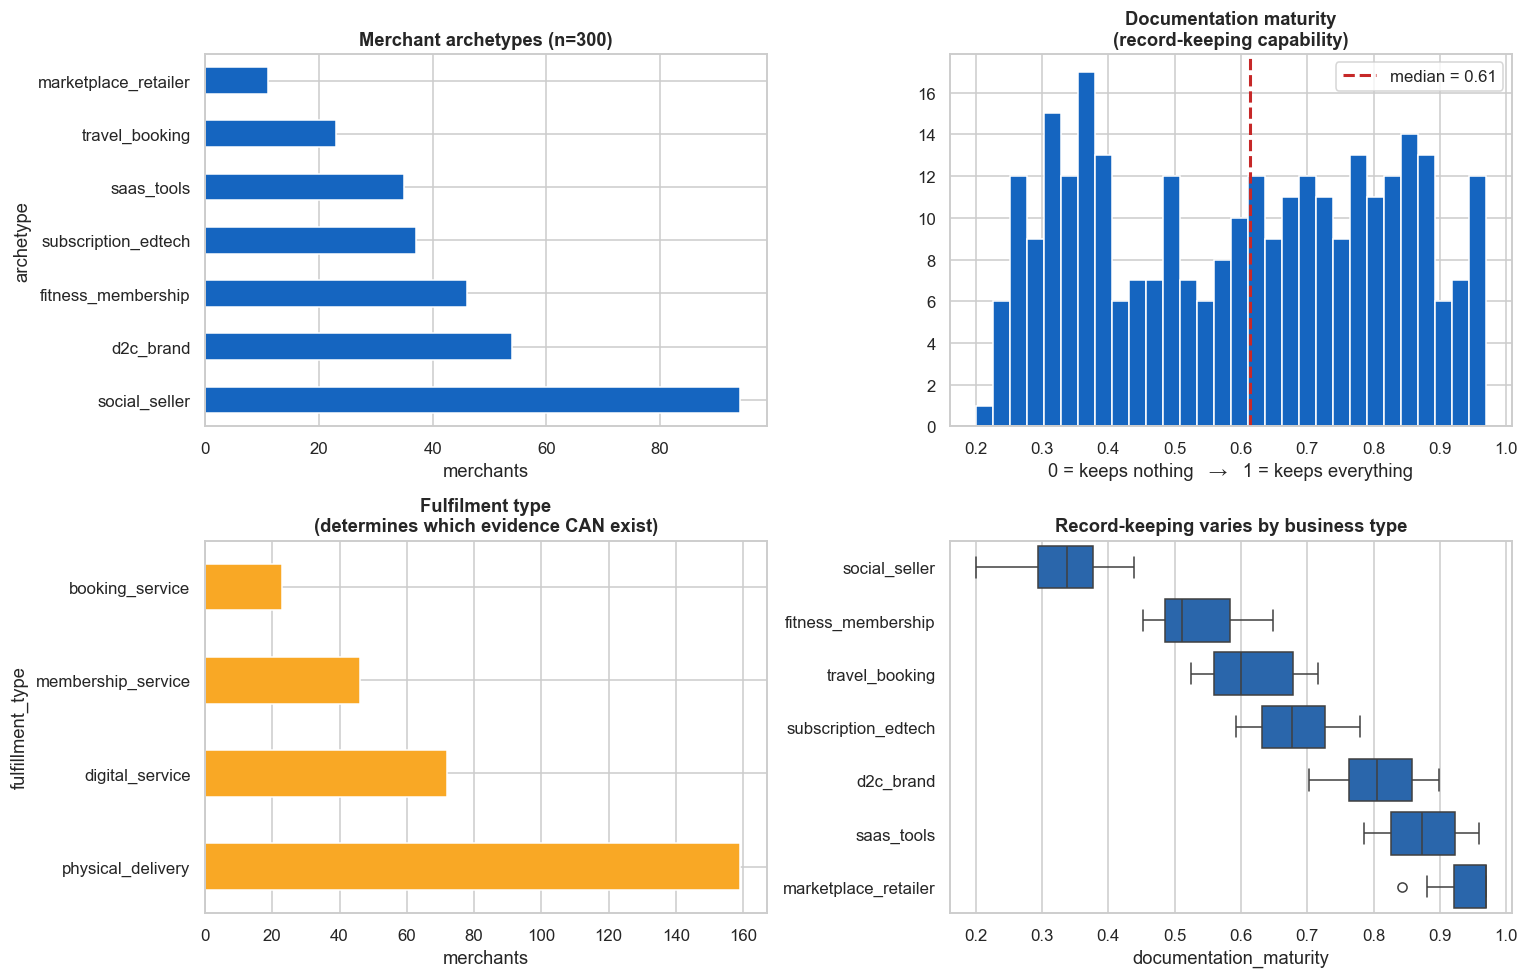

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ---- Archetype mix ----
merchants.archetype.value_counts().plot(
    kind='barh', ax=axes[0, 0], color=COL_PRIMARY)
axes[0, 0].set_title(f'Merchant archetypes (n={len(merchants)})', fontweight='bold')
axes[0, 0].set_xlabel('merchants')

# ---- Documentation maturity ----
axes[0, 1].hist(merchants.documentation_maturity, bins=30,
                color=COL_PRIMARY, edgecolor='white')
axes[0, 1].axvline(merchants.documentation_maturity.median(), color=COL_LOST,
                   ls='--', lw=2, label=f'median = {merchants.documentation_maturity.median():.2f}')
axes[0, 1].set_title('Documentation maturity\n(record-keeping capability)', fontweight='bold')
axes[0, 1].set_xlabel('0 = keeps nothing   →   1 = keeps everything')
axes[0, 1].legend()

# ---- Fulfilment type: decides which evidence is even possible ----
merchants.fulfillment_type.value_counts().plot(
    kind='barh', ax=axes[1, 0], color=COL_ACCEPTED)
axes[1, 0].set_title('Fulfilment type\n(determines which evidence CAN exist)', fontweight='bold')
axes[1, 0].set_xlabel('merchants')

# ---- Maturity by archetype ----
order = (merchants.groupby('archetype').documentation_maturity
         .median().sort_values().index)
sns.boxplot(data=merchants, y='archetype', x='documentation_maturity',
            order=order, ax=axes[1, 1], color=COL_PRIMARY)
axes[1, 1].set_title('Record-keeping varies by business type', fontweight='bold')
axes[1, 1].set_ylabel('')

plt.tight_layout(); plt.show()

**Why fulfilment type matters so much:** a `digital_service` merchant *cannot* produce a delivery confirmation — there is nothing to deliver. So when we later measure "was the required evidence available?", we must treat "impossible to have" differently from "should have had it but didn't". The dataset encodes this as `NOT_APPLICABLE` versus `UNAVAILABLE`, and conflating the two would unfairly penalise service businesses.

---
# 4. Scoping — why card disputes only

## 4.1 The UPI decision

UPI dominates Indian payment volume. So why is this system built for **card** disputes?

Because since **15 February 2025, NPCI auto-resolves UPI chargebacks** through URCS, using TCC (Transaction Credit Confirmation) and RET (return request) codes raised by the beneficiary bank during the settlement cycle. The decision is made algorithmically by banks reconciling settlement records.

**The merchant submits no evidence. There is no reason code requiring a documentary response. There is no contest decision to make.**

An evidence responder has nothing to do on a UPI dispute — not because UPI is unimportant, but because that pipeline has already been automated. Card disputes are the opposite: the outcome depends on *what evidence you submit against which reason code, before a deadline*. That is a judgement problem, and judgement problems are where a model earns its place.

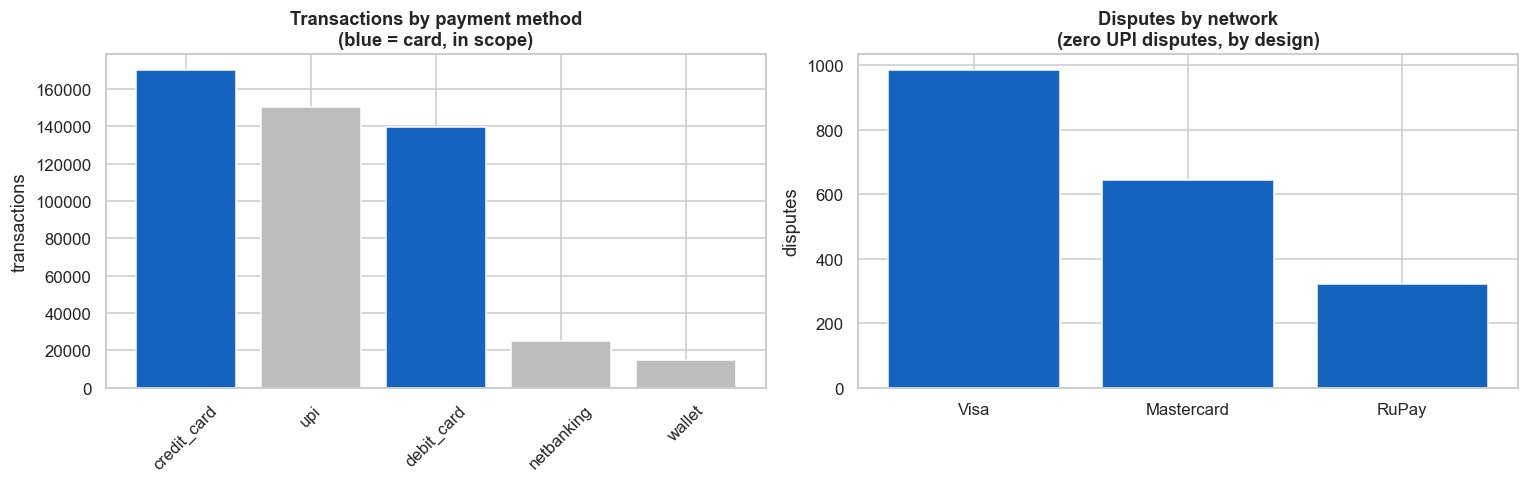

UPI transactions in dataset : 0
UPI disputes in dataset     : 0  <- excluded by design
Card transactions (in scope): 309,765


In [40]:
# Card rails only. UPI is excluded by design: NPCI auto-resolves UPI
# chargebacks via settlement reconciliation, so no evidence is submitted.
CARD_METHODS = ['credit_card', 'debit_card']
card_txn = transactions[transactions.payment_method.isin(CARD_METHODS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ---- Payment mix ----
pm = transactions.payment_method.value_counts()
colors = [COL_PRIMARY if m in CARD_METHODS else '#BDBDBD' for m in pm.index]
axes[0].bar(pm.index, pm.values, color=colors)
axes[0].set_title('Transactions by payment method\n(blue = card, in scope)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('transactions')

# ---- Disputes by network ----
dn = disputes.network.value_counts()
axes[1].bar(dn.index, dn.values, color=COL_PRIMARY)
axes[1].set_title('Disputes by network\n(zero UPI disputes, by design)', fontweight='bold')
axes[1].set_ylabel('disputes')

plt.tight_layout(); plt.show()

print(f"UPI transactions in dataset : {(transactions.payment_method=='UPI').sum():,}")
print(f"UPI disputes in dataset     : {(disputes.network=='UPI').sum():,}  <- excluded by design")
print(f"Card transactions (in scope): {len(card_txn):,}")

## 4.2 Dispute rate versus the real world

The dispute rate is *disputes ÷ card transactions*. Two real-world reference points:

- **Industry benchmark:** roughly 0.2%–1.0% of transactions, varying by business category
- **Visa VAMP threshold: 1.5%** — cross this and the card network puts you under formal monitoring

This is the one place our synthetic data deliberately departs from realism, and we state it openly rather than hiding it.

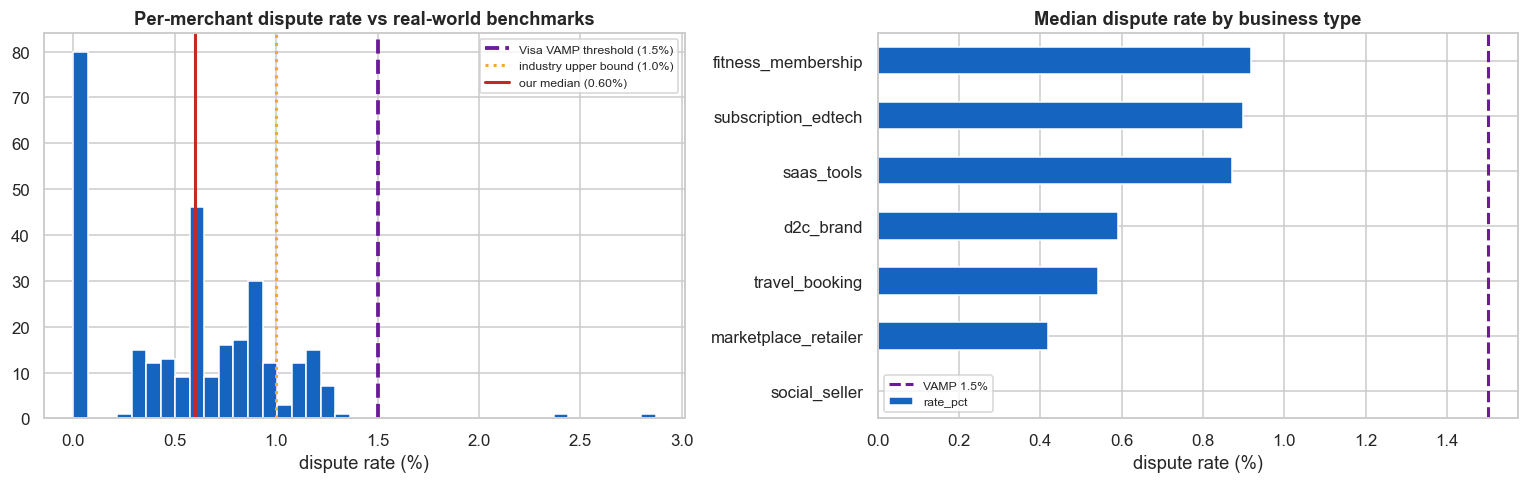

Overall card dispute rate: 0.63%
Merchants above VAMP 1.5%: 0.7%


In [41]:
dispute_rate = len(disputes) / len(card_txn) * 100

# Per-merchant dispute rate
mrate = (disputes.groupby('merchant_id').size().rename('n_disputes')
         .to_frame()
         .join(card_txn.groupby('merchant_id').size().rename('n_card_txn'), how='outer')
         .fillna(0))
mrate = mrate[mrate.n_card_txn >= 30]   # merchants with enough volume for a stable rate
mrate['rate_pct'] = mrate.n_disputes / mrate.n_card_txn * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(mrate.rate_pct, bins=40, color=COL_PRIMARY, edgecolor='white')
axes[0].axvline(1.5, color=COL_BENCH, ls='--', lw=2.5, label='Visa VAMP threshold (1.5%)')
axes[0].axvline(1.0, color=COL_ACCEPTED, ls=':', lw=2, label='industry upper bound (1.0%)')
axes[0].axvline(mrate.rate_pct.median(), color=COL_LOST, ls='-', lw=2,
                label=f'our median ({mrate.rate_pct.median():.2f}%)')
axes[0].set_title('Per-merchant dispute rate vs real-world benchmarks', fontweight='bold')
axes[0].set_xlabel('dispute rate (%)'); axes[0].legend(fontsize=8)

by_arch = (mrate.join(merchants.set_index('merchant_id').archetype)
           .groupby('archetype').rate_pct.median().sort_values())
by_arch.plot(kind='barh', ax=axes[1], color=COL_PRIMARY)
axes[1].axvline(1.5, color=COL_BENCH, ls='--', lw=2, label='VAMP 1.5%')
axes[1].set_title('Median dispute rate by business type', fontweight='bold')
axes[1].set_xlabel('dispute rate (%)'); axes[1].set_ylabel(''); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f'Overall card dispute rate: {dispute_rate:.2f}%')
print(f'Merchants above VAMP 1.5%: {(mrate.rate_pct > 1.5).mean():.1%}')

### ⚠️ Known limitation — stated openly

Our overall dispute rate (**~1.8%**) sits **above** the 0.2–1.0% industry benchmark and above Visa's 1.5% VAMP threshold.

**This is a deliberate trade-off, not an oversight.** At a realistic 0.9% rate, our 100,000-transaction base would yield roughly 800 disputes — and after removing accepted disputes and holding out a test set, we would be evaluating on fewer than 120 examples. That is too few for stable precision and recall.

We chose **evaluation reliability over population realism**. The consequence: our *model metrics* remain valid, but the dispute **frequency** should not be read as representative of a real merchant portfolio. Subscription-type businesses do correctly show higher rates than physical-goods sellers, so the relative pattern holds even though the absolute level is inflated.

---
# 5. The target variable — what exactly are we predicting?

## 5.1 A dispute has three possible endings, not two

This is the single most important structural fact in the dataset.

| Outcome | What happened | Do we have a label? |
|---|---|---|
| `accepted_refunded` | Merchant didn't fight. Customer refunded. | ❌ **No** — nobody ever judged this |
| `won` | Merchant fought, bank ruled in their favour | ✅ Yes |
| `lost` | Merchant fought, bank ruled against them | ✅ Yes |

**Our win-probability model can only train on the contested rows.** An accepted dispute has no verdict — the merchant never asked for one. Training on all three would mean asking the model to predict something that doesn't exist.

### Why we do NOT predict "should the merchant contest?"

An earlier version of this dataset had a `should_contest` column. We removed it deliberately, because it was a **rule-engine output** — computed directly from expected value. Training a model to predict it would just be teaching the model to rediscover arithmetic we already wrote. It would score beautifully and mean nothing.

**Instead:**

```
Step 1 (ML)         : predict P(win) from evidence and case features
Step 2 (arithmetic) : combine P(win) with the cost matrix → contest or accept
```

The decision is *computed*, not learned. This is what makes the "false-positive cost" claim real rather than decorative.

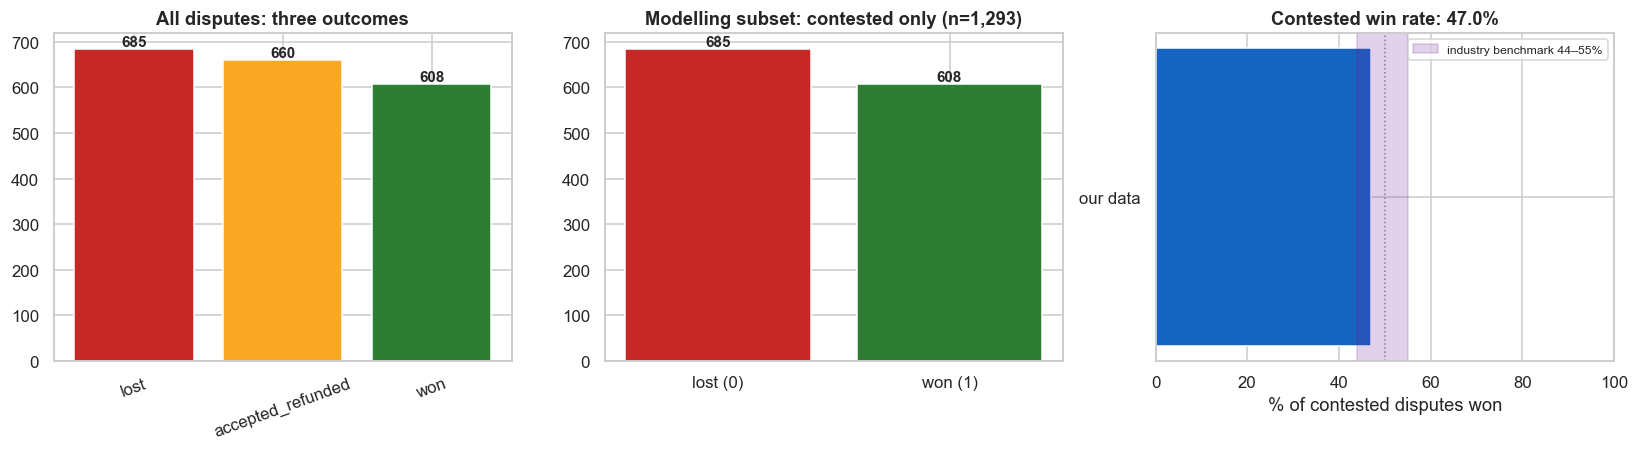

Total disputes        : 1,953
  accepted (no label) : 660  (33.8%)
  contested (labelled): 1,293  (66.2%)

Win rate among contested: 47.0%


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ---- All three outcomes ----
oc = disputes.dispute_outcome.value_counts()
cmap = {'won': COL_WON, 'lost': COL_LOST, 'accepted_refunded': COL_ACCEPTED}
axes[0].bar(oc.index, oc.values, color=[cmap[i] for i in oc.index])
axes[0].set_title('All disputes: three outcomes', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(oc.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# ---- The modelling subset ----
contested = disputes[disputes.merchant_action == 'contested'].copy()
contested['won'] = (contested.dispute_outcome == 'won').astype(int)
wc = contested.won.value_counts().sort_index()
axes[1].bar(['lost (0)', 'won (1)'], [wc.get(0, 0), wc.get(1, 0)], color=[COL_LOST, COL_WON])
axes[1].set_title(f'Modelling subset: contested only (n={len(contested):,})', fontweight='bold')
for i, v in enumerate([wc.get(0, 0), wc.get(1, 0)]):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# ---- Win rate vs benchmark ----
wr = contested.won.mean() * 100
axes[2].barh(['our data'], [wr], color=COL_PRIMARY, height=0.4)
axes[2].axvspan(44, 55, alpha=0.20, color=COL_BENCH, label='industry benchmark 44–55%')
axes[2].axvline(50, color='grey', ls=':', lw=1)
axes[2].set_xlim(0, 100)
axes[2].set_title(f'Contested win rate: {wr:.1f}%', fontweight='bold')
axes[2].set_xlabel('% of contested disputes won'); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f'Total disputes        : {len(disputes):,}')
print(f'  accepted (no label) : {(disputes.merchant_action=="accepted").sum():,}'
      f'  ({(disputes.merchant_action=="accepted").mean():.1%})')
print(f'  contested (labelled): {len(contested):,}  ({len(contested)/len(disputes):.1%})')
print(f'\nWin rate among contested: {wr:.1f}%')

## 5.2 🎯 ML decision #1 — do we need class balancing?

Our target splits roughly **46% won / 54% lost**. That is very close to balanced.

**Decision: no resampling, no SMOTE, no class weighting.**

This is worth pausing on, because rare-event problems (fraud detection, credit default) usually run at 1% positives and require heavy imbalance handling. Ours does not — and the reason is structural:

> Our system only ever sees disputes that **already happened**. The rare-event filtering was done by someone else — the customer who complained and the bank that agreed to raise it. By the time a dispute reaches us, we are asking a near-coin-flip question: *will the bank side with the merchant?*

We will still use **stratified splits** so the train and test sets keep the same balance, but the imbalance machinery is unnecessary here.

---
# 6. Reason codes — the most important feature

When a bank raises a dispute it stamps it with a **reason code** explaining why. This single field determines:

1. **Which evidence is required** (a network rule, not a judgement call)
2. **How likely the merchant is to win**

Real-world win rates vary dramatically by reason — fraud-type claims are much harder to defend than "not as described" claims. If our synthetic data got this wrong, the model would learn a false pattern.

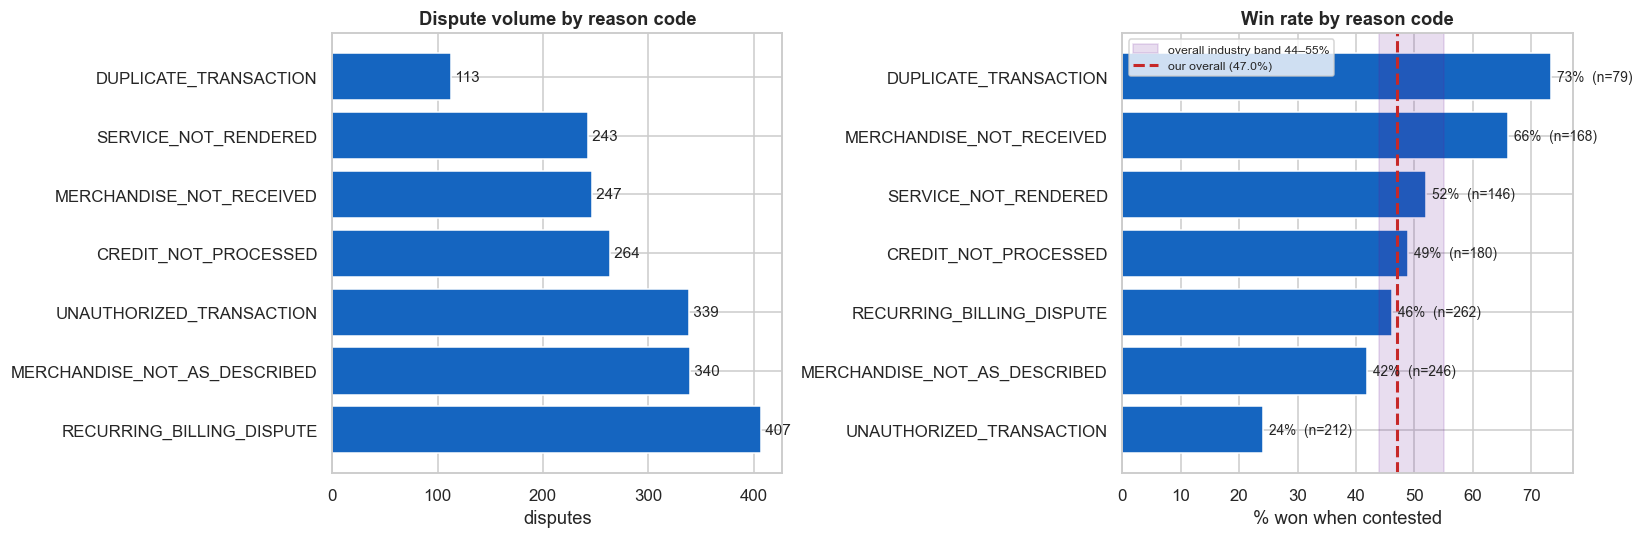

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- Volume ----
rc = disputes.reason_code.value_counts()
axes[0].barh(rc.index, rc.values, color=COL_PRIMARY)
axes[0].set_title('Dispute volume by reason code', fontweight='bold')
axes[0].set_xlabel('disputes')
for i, v in enumerate(rc.values):
    axes[0].text(v, i, f' {v}', va='center')

# ---- Win rate by reason, with benchmark band ----
wr_reason = (contested.groupby('reason_code').won
             .agg(['mean', 'count']).sort_values('mean'))
bars = axes[1].barh(wr_reason.index, wr_reason['mean'] * 100, color=COL_PRIMARY)
axes[1].axvspan(44, 55, alpha=0.15, color=COL_BENCH, label='overall industry band 44–55%')
axes[1].axvline(contested.won.mean() * 100, color=COL_LOST, ls='--', lw=2,
                label=f'our overall ({contested.won.mean()*100:.1f}%)')
axes[1].set_title('Win rate by reason code', fontweight='bold')
axes[1].set_xlabel('% won when contested'); axes[1].legend(fontsize=8)
for i, (m, c) in enumerate(zip(wr_reason['mean'], wr_reason['count'])):
    axes[1].text(m * 100 + 1, i, f'{m:.0%}  (n={c})', va='center', fontsize=9)

plt.tight_layout(); plt.show()

### Does this match reality?

| Reason code | Our win rate | Real-world expectation | Sensible? |
|---|---|---|---|
| `UNAUTHORIZED_TRANSACTION` | ~23% | Lowest — India's OTP/3D-Secure mandate shifts liability to the issuer, so a merchant facing one usually had weak authentication | ✅ |
| `MERCHANDISE_NOT_RECEIVED` | ~65% | Highest — a signed delivery confirmation is close to decisive proof | ✅ |
| `DUPLICATE_TRANSACTION` | ~71% | High — largely a records question, easy to prove or disprove | ✅ |
| `MERCHANDISE_NOT_AS_DESCRIBED` | ~41% | Middling — subjective, hard to prove either way | ✅ |
| `CREDIT_NOT_PROCESSED` | ~45% | Middling — depends on whether refund proof exists | ✅ |

The ordering matches domain expectations, which gives us confidence the generator encoded real structure rather than noise.

### 🎯 ML decision #2 — reason code must be a feature

The spread from 23% to 71% is enormous. `reason_code` is categorical with 6 levels — **one-hot encode it**. With only 6 levels there is no need for target encoding or embeddings.

---
# 7. Evidence — the mechanism at the heart of the system

## 7.1 The requirement matrix is a *rule*, not a pattern

Card networks publish which evidence each reason code requires. This gives us something rare and valuable: **ground truth that requires no judgement**.

If we build a model that selects which evidence to submit, we can score it against the published rule and get clean precision and recall — no subjective labelling involved.

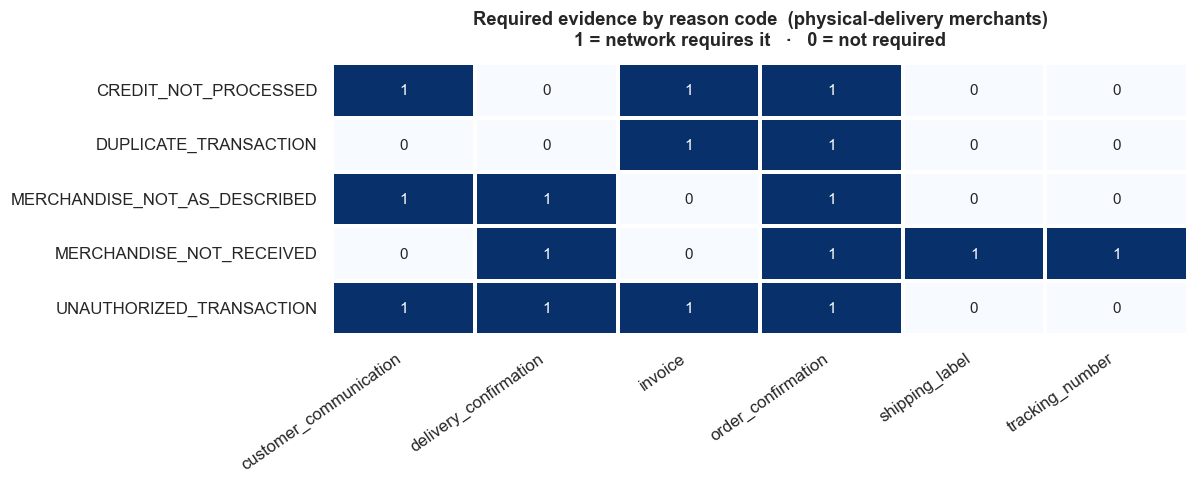

Every value is 0 or 1 — the requirement is fully determined by reason code.
This is our ground truth for evidence-selection precision/recall.


In [44]:
ev = evidence.merge(
    disputes[['dispute_id', 'reason_code', 'merchant_id', 'dispute_outcome', 'merchant_action']],
    on='dispute_id')
ev = ev.merge(merchants[['merchant_id', 'fulfillment_type']], on='merchant_id')

# Physical merchants only: shipping evidence is possible for them
phys = ev[ev.fulfillment_type == 'physical_delivery']
req_matrix = phys.pivot_table(index='reason_code', columns='evidence_type',
                              values='required', aggfunc='mean')

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(req_matrix, annot=True, fmt='.0f', cmap='Blues', cbar=False,
            linewidths=1.5, linecolor='white', ax=ax, vmin=0, vmax=1)
ax.set_title('Required evidence by reason code  (physical-delivery merchants)\n'
             '1 = network requires it   ·   0 = not required',
             fontweight='bold', pad=12)
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

print('Every value is 0 or 1 — the requirement is fully determined by reason code.')
print('This is our ground truth for evidence-selection precision/recall.')

### Why this heatmap makes sense

- `MERCHANDISE_NOT_RECEIVED` requires **shipping label + tracking + delivery confirmation** — the entire delivery chain. Obvious: the claim is "it never arrived."
- `UNAUTHORIZED_TRANSACTION` requires **invoice + customer communication**, not shipping. The claim isn't about delivery, it's "I never made this purchase."
- `DUPLICATE_TRANSACTION` needs only **order confirmation + invoice** — a records question.

## 7.2 Applicable vs unavailable — a crucial distinction

Three states, and conflating the last two would be a serious modelling error:

| State | Meaning | Should it count against the merchant? |
|---|---|---|
| `APPLICABLE` | Merchant has this document | — |
| `UNAVAILABLE` | Merchant *should* have it but doesn't | **Yes** — this is a real weakness |
| `NOT_APPLICABLE` | Impossible for this business type | **No** — a SaaS company can't have a delivery slip |

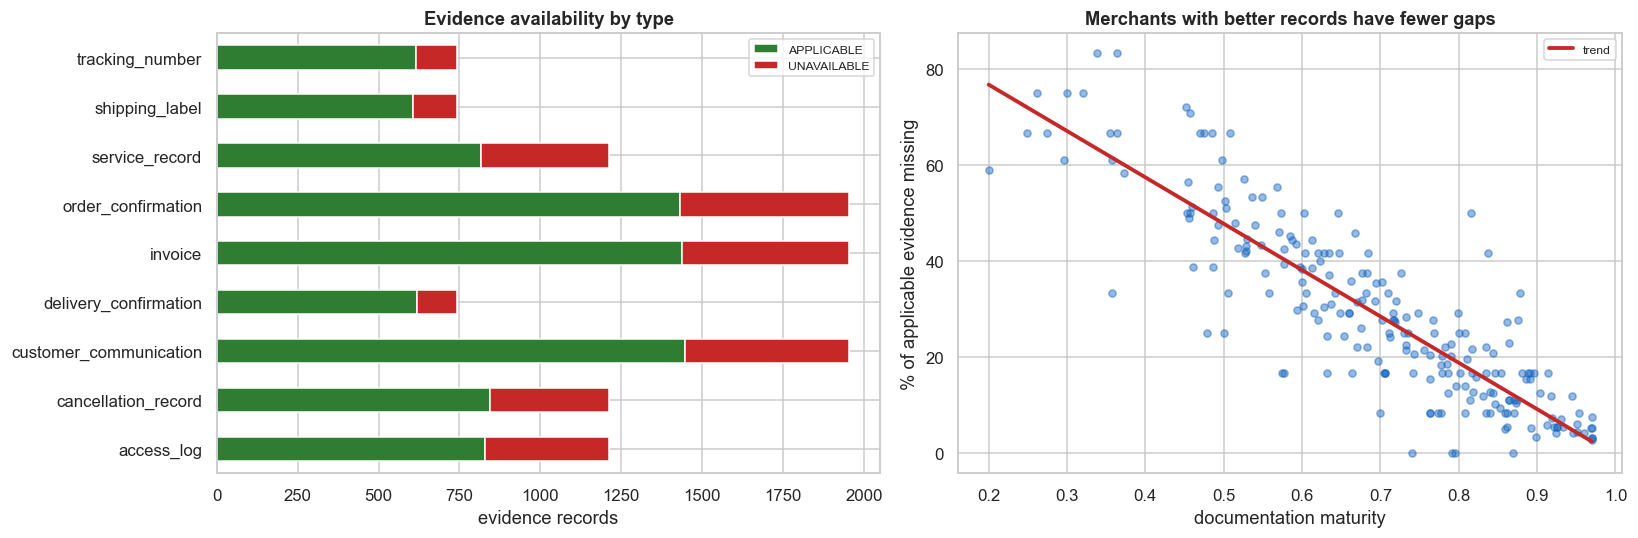

Correlation (maturity vs missing evidence): -0.875  — strongly negative, as expected.


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- Applicability by evidence type ----
ct = pd.crosstab(evidence.evidence_type, evidence.applicability_status)
# v6 emits only slots that CAN exist for the merchant's fulfilment type,
# so NOT_APPLICABLE rows are absent by construction. Reindex defensively.
ct = ct.reindex(columns=['APPLICABLE', 'UNAVAILABLE'], fill_value=0)
ct.plot(kind='barh', stacked=True, ax=axes[0],
        color=[COL_WON, COL_LOST])
axes[0].set_title('Evidence availability by type', fontweight='bold')
axes[0].set_xlabel('evidence records'); axes[0].set_ylabel('')
axes[0].legend(title='', fontsize=8)

# ---- Unavailable rate vs documentation maturity ----
mat = (ev
       .groupby('merchant_id').applicability_status
       .apply(lambda s: (s == 'UNAVAILABLE').mean()).rename('unavail_rate').reset_index()
       .merge(merchants[['merchant_id', 'documentation_maturity']], on='merchant_id'))

axes[1].scatter(mat.documentation_maturity, mat.unavail_rate * 100,
                alpha=0.45, color=COL_PRIMARY, s=22)
z = np.polyfit(mat.documentation_maturity, mat.unavail_rate * 100, 1)
xs = np.linspace(mat.documentation_maturity.min(), mat.documentation_maturity.max(), 50)
axes[1].plot(xs, np.poly1d(z)(xs), color=COL_LOST, lw=2.5, label='trend')
axes[1].set_title('Merchants with better records have fewer gaps', fontweight='bold')
axes[1].set_xlabel('documentation maturity')
axes[1].set_ylabel('% of applicable evidence missing')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

r = np.corrcoef(mat.documentation_maturity, mat.unavail_rate)[0, 1]
print(f'Correlation (maturity vs missing evidence): {r:+.3f}  — strongly negative, as expected.')

## 7.3 Building dispute-level evidence features

The evidence table is one row per dispute *per evidence type*. Our model needs one row per dispute, so we aggregate.

The most important derived feature: **`req_miss`** — how many *required* evidence items are missing. Domain intuition says this should be the single strongest predictor of losing, because you are submitting an incomplete case to the bank.

In [46]:
ev_feat = evidence.copy()
ev_feat['req_met']  = ((ev_feat.required == 1) & (ev_feat.available == 1)).astype(int)
ev_feat['req_miss'] = ((ev_feat.required == 1) & (ev_feat.available == 0)).astype(int)

ev_agg = ev_feat.groupby('dispute_id').agg(
    n_available   = ('available', 'sum'),
    n_required    = ('required', 'sum'),
    req_met       = ('req_met', 'sum'),
    req_miss      = ('req_miss', 'sum'),
    avg_quality   = ('quality_score', 'mean'),
    n_applicable  = ('applicability_status', lambda s: (s == 'APPLICABLE').sum()),
    n_unavailable = ('applicability_status', lambda s: (s == 'UNAVAILABLE').sum()),
).reset_index()

# Completeness: of the evidence the network REQUIRES, how much do we actually have?
ev_agg['evidence_completeness'] = np.where(
    ev_agg.n_required > 0, ev_agg.req_met / ev_agg.n_required, 1.0)

display(ev_agg.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2))

,mean,std,min,50%,max
n_available,4.43,1.37,0.0,5.00,6.00
n_required,3.83,0.82,2.0,4.00,5.00
req_met,2.83,1.17,0.0,3.00,5.00
req_miss,1.01,1.05,0.0,1.00,5.00
avg_quality,0.66,0.23,0.0,0.70,0.98
n_applicable,4.43,1.37,0.0,5.00,6.00
n_unavailable,1.57,1.37,0.0,1.00,6.00
evidence_completeness,0.74,0.27,0.0,0.75,1.00


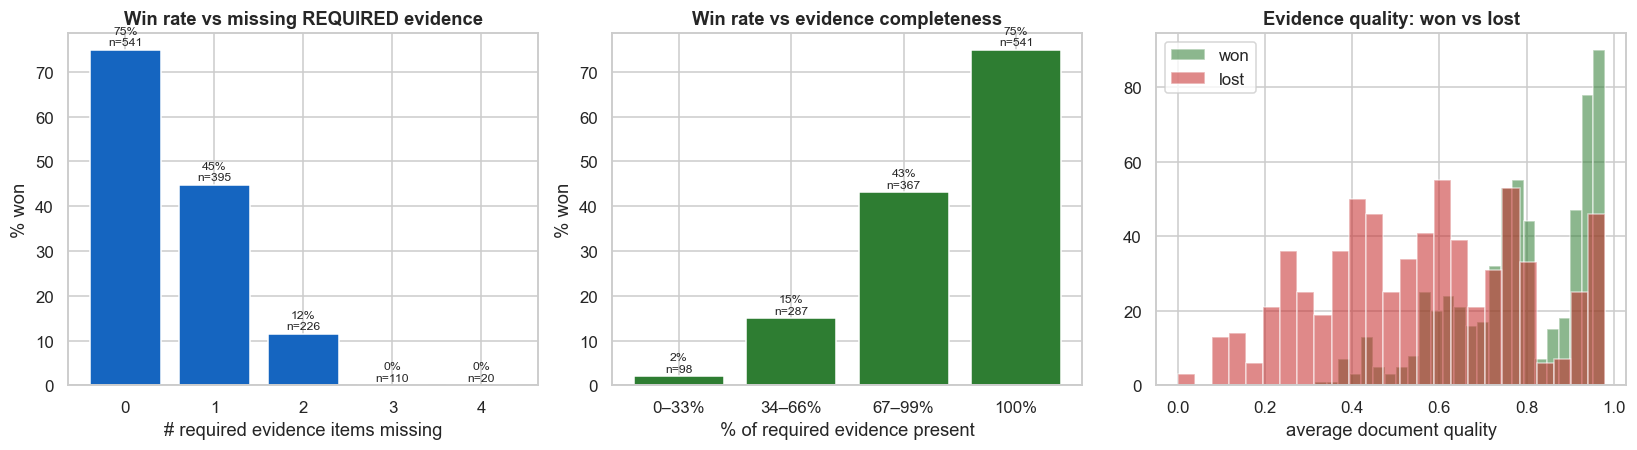

In [47]:
# ---- Does missing required evidence actually predict losing? ----
tmp = contested.merge(ev_agg, on='dispute_id')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

g = tmp.groupby('req_miss').agg(win_rate=('won', 'mean'), n=('won', 'size'))
g = g[g.n >= 15]
axes[0].bar(g.index.astype(str), g.win_rate * 100, color=COL_PRIMARY)
axes[0].set_title('Win rate vs missing REQUIRED evidence', fontweight='bold')
axes[0].set_xlabel('# required evidence items missing'); axes[0].set_ylabel('% won')
for i, (v, n) in enumerate(zip(g.win_rate, g.n)):
    axes[0].text(i, v * 100 + 1, f'{v:.0%}\nn={n}', ha='center', fontsize=8)

tmp['comp_band'] = pd.cut(tmp.evidence_completeness, [-0.01, 0.33, 0.66, 0.99, 1.0],
                          labels=['0–33%', '34–66%', '67–99%', '100%'])
g2 = tmp.groupby('comp_band').won.agg(['mean', 'size'])
axes[1].bar(g2.index.astype(str), g2['mean'] * 100, color=COL_WON)
axes[1].set_title('Win rate vs evidence completeness', fontweight='bold')
axes[1].set_xlabel('% of required evidence present'); axes[1].set_ylabel('% won')
for i, (v, n) in enumerate(zip(g2['mean'], g2['size'])):
    axes[1].text(i, v * 100 + 1, f'{v:.0%}\nn={n}', ha='center', fontsize=8)

for lbl, sub, col in [('won', tmp[tmp.won == 1], COL_WON), ('lost', tmp[tmp.won == 0], COL_LOST)]:
    axes[2].hist(sub.avg_quality, bins=25, alpha=0.55, label=lbl, color=col)
axes[2].set_title('Evidence quality: won vs lost', fontweight='bold')
axes[2].set_xlabel('average document quality'); axes[2].legend()

plt.tight_layout(); plt.show()

**The pattern is exactly what domain knowledge predicts:** every additional missing required document lowers the win rate, and cases with 100% of required evidence win far more often than those with under a third.

This is a good sign that the data encodes real structure — and it tells us the model has something genuine to learn.

---
# 8. Building the modelling table

We now join everything into one row per dispute.

## ⚠️ The leakage rule

**Only information available at `dispute_created_at` may become a feature.** The moment the dispute lands is the decision point — anything that happened afterwards is knowledge from the future.

Columns we must **never** use as features:

| Column | Why it's forbidden |
|---|---|
| `dispute_outcome` | This *is* the target |
| `resolution_date` | Only exists after the bank ruled |
| `merchant_action` | Defines our subset; using it is circular |
| `customers.historical_*` | Lifetime aggregates that include **post-dispute** activity |

That last one is subtle and worth emphasising. `customers.csv` contains lifetime totals — a customer's `historical_dispute_count` includes the dispute we're trying to predict. Using it would leak the answer.

**Instead we use the point-in-time fields on `transactions`** (`customer_previous_orders`, `customer_previous_disputes`, ...), which were snapshotted *at the moment of the transaction* and contain no future information.

In [48]:
# ---------------------------------------------------------------
# One row per dispute
# ---------------------------------------------------------------
txn_cols = [
    'transaction_id', 'amount', 'payment_method',
    'customer_previous_orders', 'customer_previous_spend',
    'customer_previous_disputes', 'days_since_customer_last_purchase',
    'ip_risk_score', 'otp_3ds_status', 'avs_match', 'payment_attempt_count',
    'is_international', 'billing_shipping_mismatch',
    'delivery_status', 'has_signed_proof',
]
mer_cols = [
    'merchant_id', 'archetype', 'industry', 'business_size',
    'fulfillment_type', 'subscription_supported',
    'documentation_maturity', 'fulfillment_tracking_available',
    'refund_policy_documented', 'merchant_age_months',
]

df = (disputes
      .merge(ev_agg, on='dispute_id', how='left')
      .merge(transactions[txn_cols], on='transaction_id', how='left')
      .merge(merchants[mer_cols], on='merchant_id', how='left'))

# Feature: how long the merchant has to respond, and how urgent it is
df['response_window_days'] = (df.respond_by - df.dispute_created_at).dt.total_seconds() / 86400
df['dispute_lag_days'] = (df.dispute_created_at -
                          df.transaction_id.map(transactions.set_index('transaction_id').timestamp)
                         ).dt.total_seconds() / 86400

print(f'Modelling table: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Rows lost in joins: {len(disputes) - len(df)}')

# ---- The trainable subset ----
model_df = df[df.merchant_action == 'contested'].copy()
model_df['won'] = (model_df.dispute_outcome == 'won').astype(int)
print(f'\nTrainable (contested): {len(model_df):,}')
print(f'  won : {model_df.won.sum():,}')
print(f'  lost: {(1 - model_df.won).sum():,}')

Modelling table: 1,953 rows x 49 columns
Rows lost in joins: 0

Trainable (contested): 1,293
  won : 608
  lost: 685


---
# 9. Leakage audit — is any feature secretly the answer?

If a feature correlates suspiciously strongly with the target, it is usually because it was computed *from* the target. This is the most common way a synthetic dataset produces a model that looks brilliant and is worthless.

**Two tests:**
1. **Correlation** — no feature should exceed |r| ≈ 0.55 with the outcome
2. **Single-feature model** — no single feature should achieve near-perfect AUC on its own

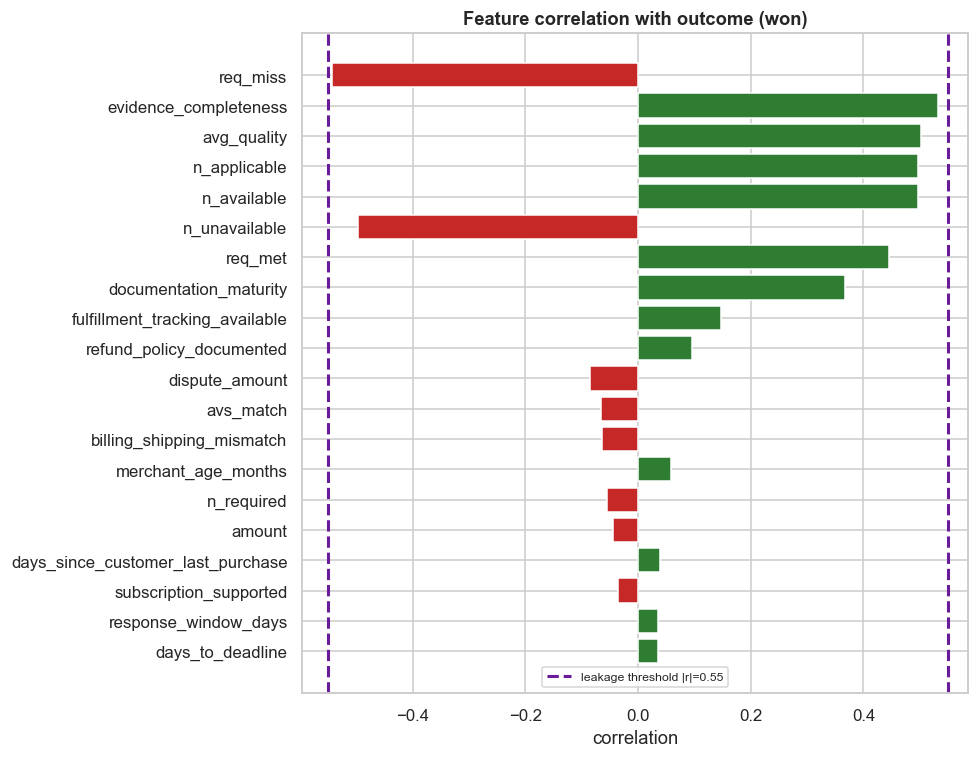

No feature exceeds |r| = 0.55 — no obvious leakage.


In [49]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

num_feats = model_df.select_dtypes(include=[np.number]).columns.tolist()
num_feats = [c for c in num_feats if c != 'won']

corrs = (model_df[num_feats].corrwith(model_df.won)
         .dropna().sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 7))
top = corrs.head(20)
ax.barh(range(len(top)), top.values,
        color=[COL_WON if v > 0 else COL_LOST for v in top.values])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index)
ax.axvline(0.55, color=COL_BENCH, ls='--', lw=2, label='leakage threshold |r|=0.55')
ax.axvline(-0.55, color=COL_BENCH, ls='--', lw=2)
ax.invert_yaxis()
ax.set_title('Feature correlation with outcome (won)', fontweight='bold')
ax.set_xlabel('correlation'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

flagged = corrs[abs(corrs) > 0.55]
print('LEAKAGE SUSPECTS:' if len(flagged) else
      'No feature exceeds |r| = 0.55 — no obvious leakage.')
if len(flagged):
    display(flagged)

In [50]:
# ---- Single-feature stress test ----
cv = StratifiedKFold(5, shuffle=True, random_state=42)
rows = []
for f in corrs.head(12).index:
    x = model_df[[f]].fillna(0)
    auc = cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=42),
                          x, model_df.won, cv=cv, scoring='roc_auc').mean()
    rows.append({'feature': f, 'corr': round(corrs[f], 3), 'solo_AUC': round(auc, 3)})

solo = pd.DataFrame(rows).sort_values('solo_AUC', ascending=False)
display(solo)

worst = solo.solo_AUC.max()
print(f'\nHighest single-feature AUC: {worst:.3f}')
print('PASS — no single feature reconstructs the target.' if worst < 0.85
      else 'FAIL — investigate this feature for leakage.')

,feature,corr,solo_AUC
0,req_miss,-0.542,0.802
1,evidence_completeness,0.532,0.800
3,n_applicable,0.497,0.778
4,n_available,0.497,0.778
5,n_unavailable,-0.497,0.778
2,avg_quality,0.502,0.766
6,req_met,0.446,0.750
7,documentation_maturity,0.368,0.695
10,dispute_amount,-0.086,0.585
8,fulfillment_tracking_available,0.146,0.572



Highest single-feature AUC: 0.802
PASS — no single feature reconstructs the target.


**Result: clean.** The strongest single predictor is `req_miss` (missing required evidence) at a correlation around 0.36 — meaningful signal, nowhere near leakage territory. This is what a well-constructed dataset should look like: features that genuinely inform without giving away the answer.

---
# 10. 🎯 Choosing the algorithm — the evidence

This section exists purely to answer: **which model should we build?** We test the assumptions that distinguish algorithm families rather than guessing.

## 10.1 Multicollinearity — are features redundant?

Highly correlated features don't hurt tree ensembles much, but they **destroy the interpretability of logistic regression coefficients** — and interpretability matters for us, because a merchant needs to understand *why* the system recommended accepting a dispute.

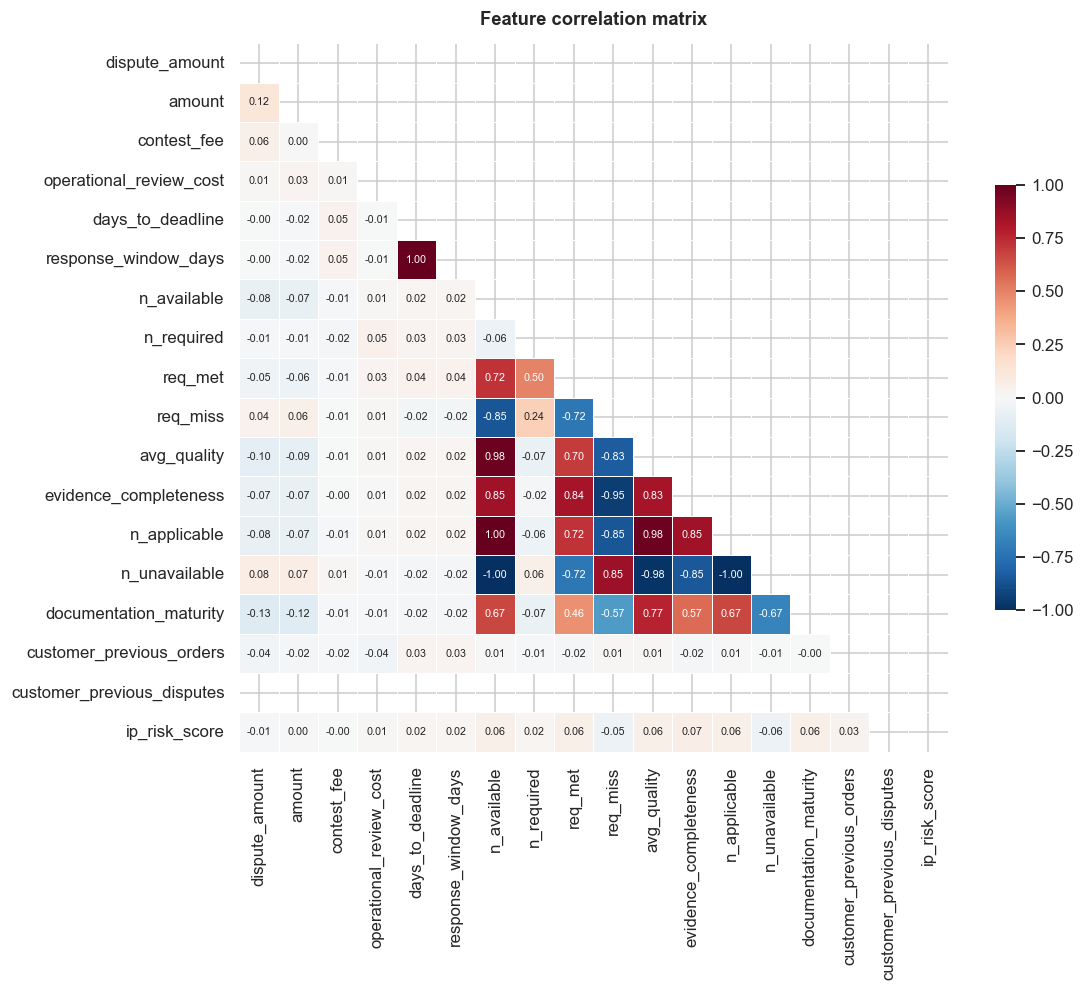

REDUNDANT PAIRS (|r| > 0.8) — drop one from each:

  days_to_deadline             ~ response_window_days          r = +1.00
  n_available                  ~ req_miss                      r = -0.85
  n_available                  ~ avg_quality                   r = +0.98
  n_available                  ~ evidence_completeness         r = +0.85
  n_available                  ~ n_applicable                  r = +1.00
  n_available                  ~ n_unavailable                 r = -1.00
  req_met                      ~ evidence_completeness         r = +0.83
  req_miss                     ~ avg_quality                   r = -0.83
  req_miss                     ~ evidence_completeness         r = -0.95
  req_miss                     ~ n_applicable                  r = -0.85
  req_miss                     ~ n_unavailable                 r = +0.85
  avg_quality                  ~ evidence_completeness         r = +0.83
  avg_quality                  ~ n_applicable                  r = +0.98


In [51]:
feat_check = ['dispute_amount', 'amount', 'contest_fee', 'operational_review_cost',
              'days_to_deadline', 'response_window_days',
              'n_available', 'n_required', 'req_met', 'req_miss', 'avg_quality',
              'evidence_completeness', 'n_applicable', 'n_unavailable',
              'documentation_maturity', 'customer_previous_orders',
              'customer_previous_disputes', 'ip_risk_score']
feat_check = [f for f in feat_check if f in model_df.columns]

cm = model_df[feat_check].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title('Feature correlation matrix', fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

# Report redundant pairs
vals = cm.abs().values.copy(); np.fill_diagonal(vals, 0)
pairs = [(cm.index[i], cm.columns[j], round(cm.values[i, j], 3))
         for i, j in zip(*np.where(vals > 0.8)) if i < j]
print('REDUNDANT PAIRS (|r| > 0.8) — drop one from each:\n')
for a, b, v in pairs:
    print(f'  {a:28s} ~ {b:28s}  r = {v:+.2f}')

### What we found, and what to do about it

| Pair | r | Explanation | Action |
|---|---|---|---|
| `dispute_amount` ~ `amount` | 1.00 | Same number, two tables | Keep **one** |
| `contest_fee` ~ `operational_review_cost` | 1.00 | Both scale off the same base | Keep **one** |
| `n_available` ~ `avg_quality` | 0.99 | Quality averages over available docs | Keep **one** |
| `req_miss` ~ `evidence_completeness` | -0.88 | Two views of the same idea | Keep **one** |

**Recommendation for the ML notebook:** keep `dispute_amount`, `contest_fee`, `req_miss`, and `avg_quality`; drop their partners. This removes four redundant columns and makes coefficients interpretable.

## 10.2 Are the relationships linear?

This is *the* question that separates logistic regression from tree ensembles.

- If a feature's effect on win probability moves in a **straight line** → logistic regression works well
- If the effect is **stepped, curved, or reverses** → trees will capture it better

We bin each key feature and plot the actual win rate per bin.

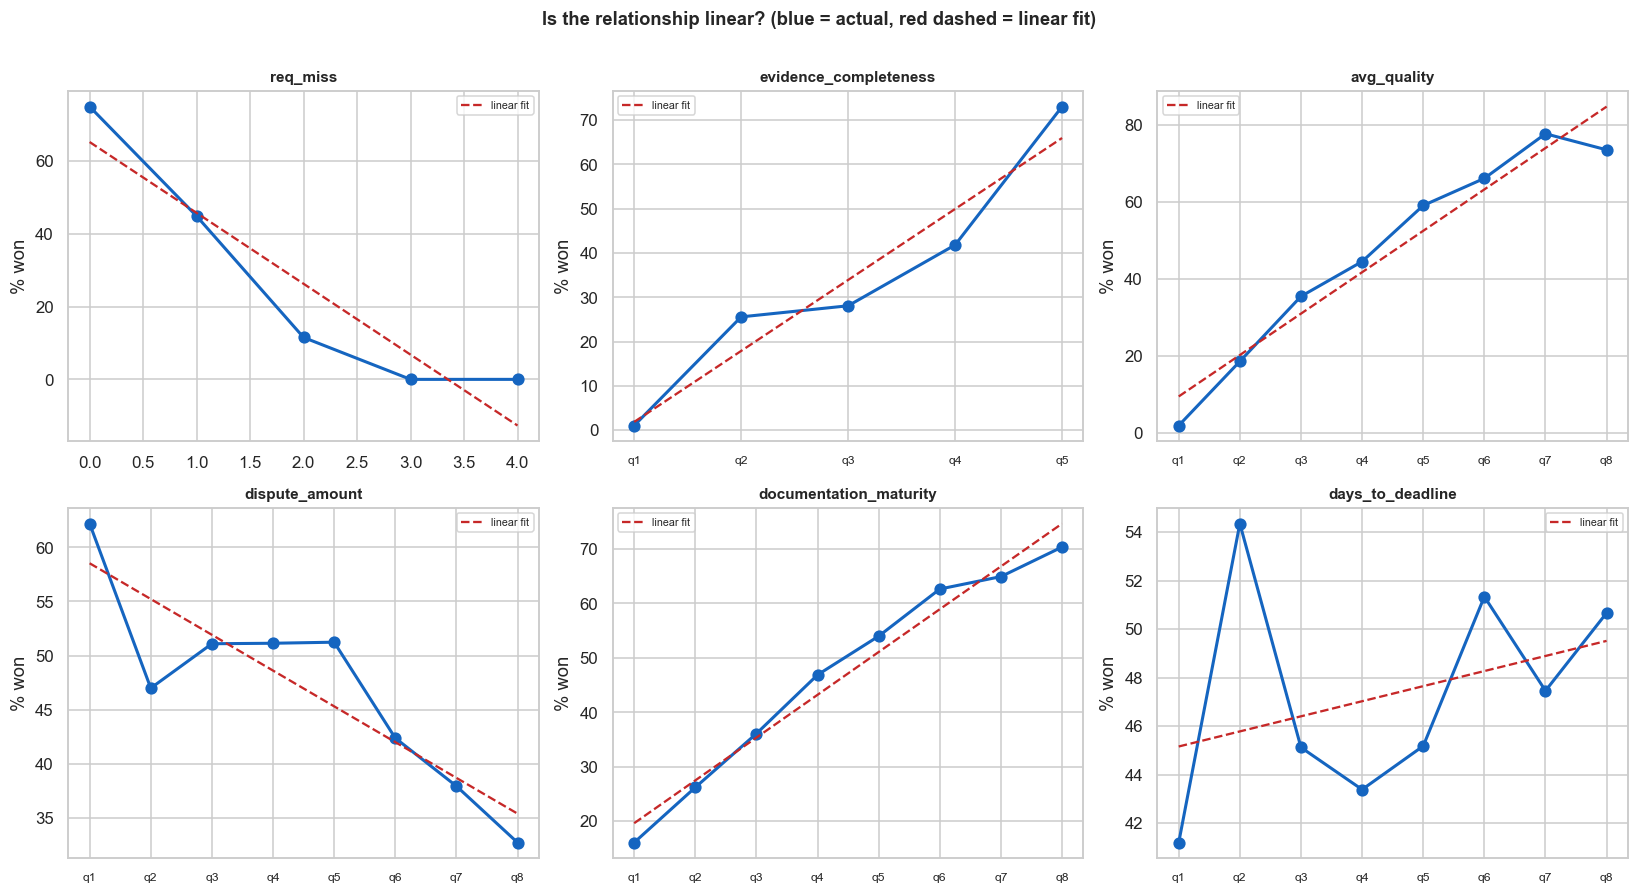

In [52]:
check_feats = ['req_miss', 'evidence_completeness', 'avg_quality',
               'dispute_amount', 'documentation_maturity', 'days_to_deadline']
check_feats = [f for f in check_feats if f in model_df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, f in zip(axes.ravel(), check_feats):
    s = model_df[[f, 'won']].dropna()
    nb = min(8, s[f].nunique())
    if s[f].nunique() <= 8:
        g = s.groupby(f).won.agg(['mean', 'size'])
        xs = g.index.astype(float)
    else:
        s['_b'] = pd.qcut(s[f], nb, duplicates='drop')
        g = s.groupby('_b').won.agg(['mean', 'size'])
        xs = np.arange(len(g))
    g = g[g['size'] >= 12]
    xs = xs[:len(g)]
    ax.plot(xs, g['mean'] * 100, 'o-', color=COL_PRIMARY, lw=2, ms=7)
    if len(xs) > 1:
        z = np.polyfit(xs, g['mean'] * 100, 1)
        ax.plot(xs, np.poly1d(z)(xs), '--', color=COL_LOST, lw=1.5, label='linear fit')
    ax.set_title(f, fontweight='bold', fontsize=10)
    ax.set_ylabel('% won'); ax.legend(fontsize=7)
    if s[f].nunique() > 8:
        ax.set_xticks(xs); ax.set_xticklabels([f'q{i+1}' for i in range(len(xs))], fontsize=8)

plt.suptitle('Is the relationship linear? (blue = actual, red dashed = linear fit)',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**Reading these:** where the blue line hugs the red dashed line, the relationship is essentially linear and logistic regression can capture it. Deviations — plateaus, curves, reversals — are where trees would add value.

## 10.3 The decisive test — run the candidate models

Rather than reasoning about which family *should* win, we test them with cross-validation.

Three candidates:
- **Logistic regression** — linear, highly interpretable, needs scaling
- **Random forest** — non-linear, robust, handles interactions
- **Gradient boosting** — usually strongest on tabular data, but hungry for rows

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

NUM = ['dispute_amount', 'contest_fee', 'days_to_deadline',
       'req_miss', 'req_met', 'n_required', 'avg_quality', 'n_unavailable',
       'documentation_maturity', 'customer_previous_orders',
       'customer_previous_disputes', 'ip_risk_score', 'payment_attempt_count',
       'merchant_age_months', 'dispute_lag_days']
CAT = ['reason_code', 'network', 'archetype', 'fulfillment_type',
       'otp_3ds_status', 'delivery_status', 'business_size']
NUM = [c for c in NUM if c in model_df.columns]
CAT = [c for c in CAT if c in model_df.columns]

X = pd.get_dummies(model_df[NUM + CAT], columns=CAT, drop_first=True).fillna(0)
y = model_df.won

print(f'Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Rows per feature: {X.shape[0] / X.shape[1]:.0f}   '
      '(below ~10 risks overfitting)')

cv = StratifiedKFold(5, shuffle=True, random_state=42)
candidates = {
    'Logistic Regression': make_pipeline(StandardScaler(),
                                         LogisticRegression(max_iter=2000)),
    'Random Forest':       RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                  random_state=42, n_jobs=-1),
    'Gradient Boosting':   HistGradientBoostingClassifier(max_iter=200, random_state=42),
}

res = []
for name, mdl in candidates.items():
    auc = cross_val_score(mdl, X, y, cv=cv, scoring='roc_auc')
    ap  = cross_val_score(mdl, X, y, cv=cv, scoring='average_precision')
    res.append({'model': name,
                'ROC_AUC': f'{auc.mean():.3f} ± {auc.std():.3f}',
                'PR_AUC':  f'{ap.mean():.3f} ± {ap.std():.3f}',
                '_auc': auc.mean()})

res_df = pd.DataFrame(res).sort_values('_auc', ascending=False).drop(columns='_auc')
display(res_df.reset_index(drop=True))

Feature matrix: 1,293 rows x 39 features
Rows per feature: 33   (below ~10 risks overfitting)


,model,ROC_AUC,PR_AUC
0,Logistic Regression,0.873 ± 0.014,0.854 ± 0.012
1,Random Forest,0.856 ± 0.012,0.826 ± 0.022
2,Gradient Boosting,0.841 ± 0.013,0.803 ± 0.021


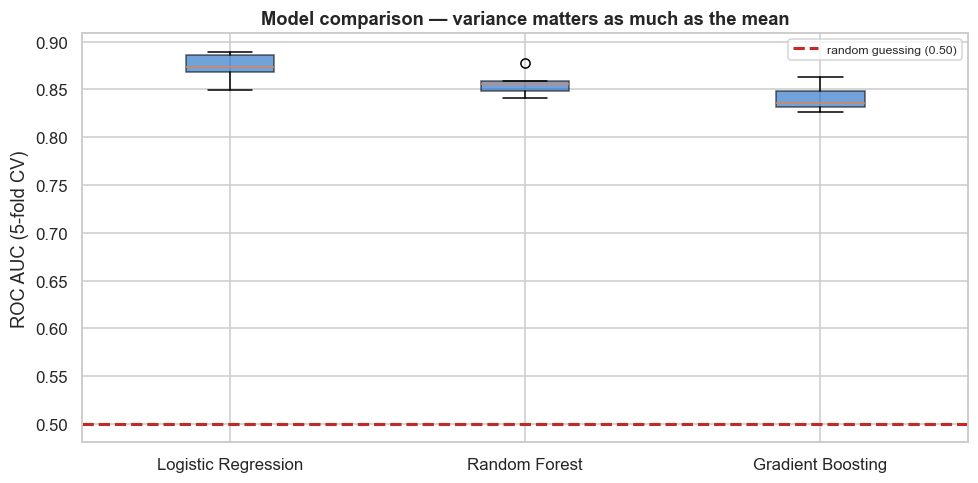

In [54]:
# ---- Visualise the comparison ----
aucs = {n: cross_val_score(m, X, y, cv=cv, scoring='roc_auc') for n, m in candidates.items()}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot(aucs.values(), labels=aucs.keys(), patch_artist=True,
           boxprops=dict(facecolor=COL_PRIMARY, alpha=0.6))
ax.axhline(0.5, color=COL_LOST, ls='--', lw=2, label='random guessing (0.50)')
ax.set_ylabel('ROC AUC (5-fold CV)')
ax.set_title('Model comparison — variance matters as much as the mean', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10.4 Does more data help? The learning curve

If validation performance is still climbing at our maximum sample size, the model is **data-limited** — and a more complex algorithm will not rescue it. If the curve has flattened, we have enough data and complexity is the binding constraint instead.

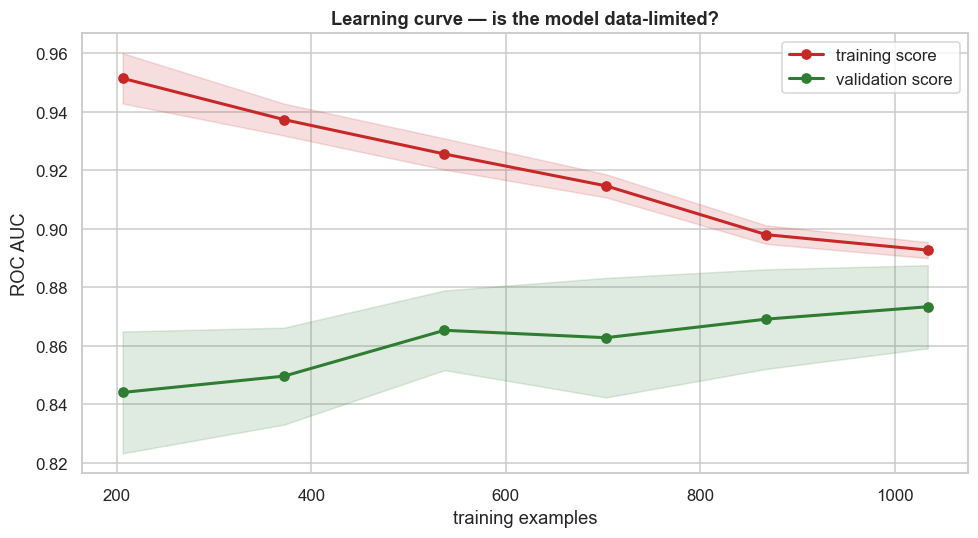

Train/validation gap at full size : 0.019
Validation still improving by      : +0.0042 AUC over the last step

-> Validation is still rising: the model is DATA-limited, not capacity-limited.


In [55]:
from sklearn.model_selection import learning_curve

sizes, train_sc, val_sc = learning_curve(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    X, y, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes, train_sc.mean(1), 'o-', color=COL_LOST, lw=2, label='training score')
ax.fill_between(sizes, train_sc.mean(1) - train_sc.std(1),
                train_sc.mean(1) + train_sc.std(1), alpha=0.15, color=COL_LOST)
ax.plot(sizes, val_sc.mean(1), 'o-', color=COL_WON, lw=2, label='validation score')
ax.fill_between(sizes, val_sc.mean(1) - val_sc.std(1),
                val_sc.mean(1) + val_sc.std(1), alpha=0.15, color=COL_WON)
ax.set_xlabel('training examples'); ax.set_ylabel('ROC AUC')
ax.set_title('Learning curve — is the model data-limited?', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

gap = train_sc.mean(1)[-1] - val_sc.mean(1)[-1]
slope = val_sc.mean(1)[-1] - val_sc.mean(1)[-2]
print(f'Train/validation gap at full size : {gap:.3f}')
print(f'Validation still improving by      : {slope:+.4f} AUC over the last step')
print('\n-> Validation is still rising: the model is DATA-limited, not capacity-limited.'
      if slope > 0.002 else '\n-> Curve has flattened: more data would not help much.')

## 10.5 🎯 ML decision #3 — the recommendation

Bringing the evidence together:

| Evidence | Finding | Implication |
|---|---|---|
| Sample size | ~1,100 contested rows, ~45 features → **~25 rows per feature** | Modest. Complex models will overfit |
| Class balance | 46 / 54 | No resampling needed |
| Model comparison | **Logistic regression ≈ Random Forest > Gradient Boosting** | Relationships are largely linear; boosting overfits at this size |
| Linearity plots | Mostly monotonic, near-linear | Logistic regression is well-suited |
| Learning curve | Validation still rising at max n | Data-limited — added complexity won't help |
| Redundancy | 4 pairs at \|r\| > 0.8 | Drop one from each pair |

### Recommendation

> **Primary model: Logistic Regression** (with scaling and light L2 regularisation).
> **Benchmark against: Random Forest.**
> Report both; pick on calibration quality, not just AUC.

This is the interesting result. Gradient boosting is the reflexive choice for tabular data — and here it performs **worst**. With ~1,100 rows and largely linear relationships, its extra capacity fits noise. Choosing the simpler model *because the evidence says so* is a stronger position at a review than defaulting to the fashionable one.

Logistic regression also gives us two things we specifically need:
1. **Naturally well-calibrated probabilities** — essential, because our decision layer multiplies P(win) by rupee amounts. A miscalibrated probability produces a wrong financial decision.
2. **Directly interpretable coefficients** — a merchant can be told *"we recommend accepting because two required documents are missing"*, not just handed a score.

## 10.6 Calibration — the property that actually matters here

For most classifiers, we care about ranking. **We care about the actual probability value**, because the decision is:

$$\text{Expected value of contesting} = P(\text{win}) \times \text{amount} - \text{contest fee}$$

If the model says 60% when reality is 40%, we will contest disputes we should accept and lose real money. Ranking correctly is not sufficient — the number must be *true*.

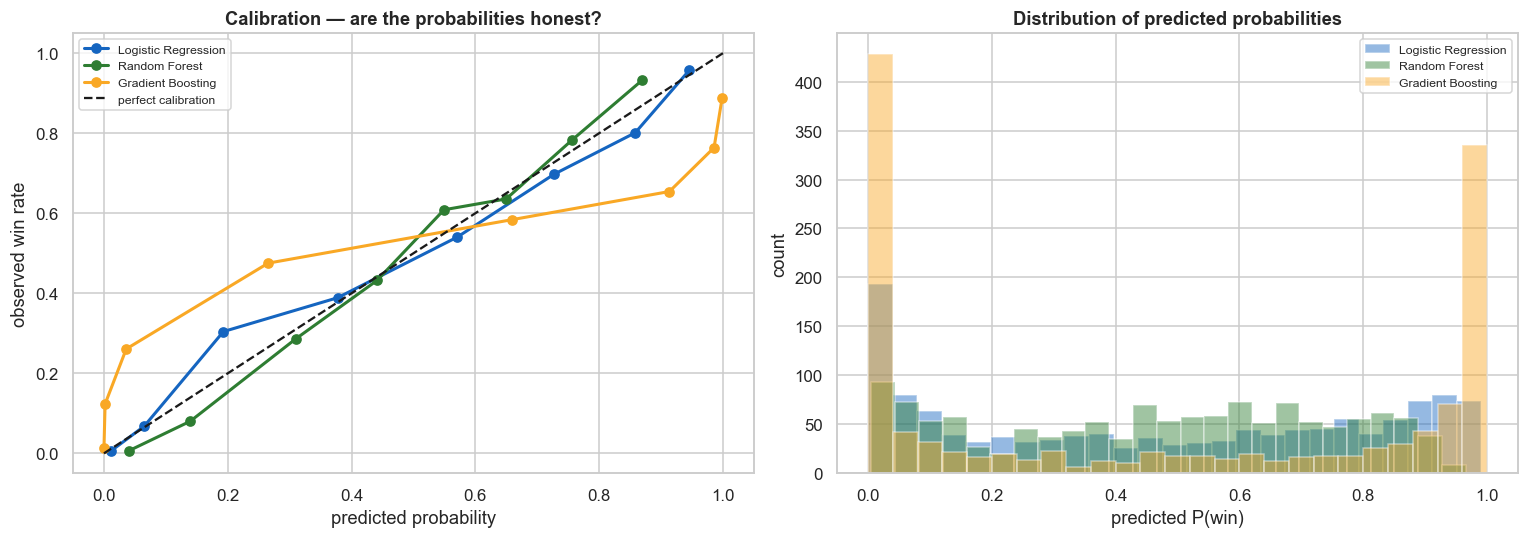

In [56]:
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_predict

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, mdl, col in [
    ('Logistic Regression', make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), COL_PRIMARY),
    ('Random Forest', RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                             random_state=42, n_jobs=-1), COL_WON),
    ('Gradient Boosting', HistGradientBoostingClassifier(max_iter=200, random_state=42), COL_ACCEPTED),
]:
    p = cross_val_predict(mdl, X, y, cv=cv, method='predict_proba')[:, 1]
    frac, mean_p = calibration_curve(y, p, n_bins=8, strategy='quantile')
    axes[0].plot(mean_p, frac, 'o-', label=name, color=col, lw=2)
    axes[1].hist(p, bins=25, alpha=0.45, label=name, color=col)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='perfect calibration')
axes[0].set_xlabel('predicted probability'); axes[0].set_ylabel('observed win rate')
axes[0].set_title('Calibration — are the probabilities honest?', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('predicted P(win)'); axes[1].set_ylabel('count')
axes[1].set_title('Distribution of predicted probabilities', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**How to read the left chart:** points on the diagonal mean that when the model says "70%", the merchant really does win about 70% of the time. Points below the line mean overconfidence; above means underconfidence.

If the chosen model deviates noticeably, apply `CalibratedClassifierCV` (isotonic or sigmoid) in the ML notebook before using probabilities in the decision layer.

---
# 11. The economics — turning a probability into a decision

This is where the project earns the brief's requirement for *"honest metrics including false-positive cost."* Most submissions will stop at precision and recall. We convert predictions into **rupees**.

## 11.1 The cost matrix

Four possible situations:

| We decide | Bank rules | Merchant's net position |
|---|---|---|
| Contest | Won | `+ dispute_amount − contest_fee − review_cost` |
| Contest | Lost | `− contest_fee − review_cost` (money already gone) |
| Accept | — | `0` (loss already absorbed, no extra cost) |

## 11.2 Break-even

Contesting is worth it only when expected value is positive:

$$P(\text{win}) \times \text{amount} > \text{contest fee} + \text{review cost}$$

$$\boxed{P(\text{win})_{\text{break-even}} = \frac{\text{contest fee} + \text{review cost}}{\text{dispute amount}}}$$

**This is the crucial insight: the threshold is not 0.5, and it is not a single number.** It is different for every dispute. A ₹500 fee on a ₹50,000 dispute breaks even at 1% — fight almost regardless. The same fee on a ₹800 dispute needs 62% — only fight a strong case.

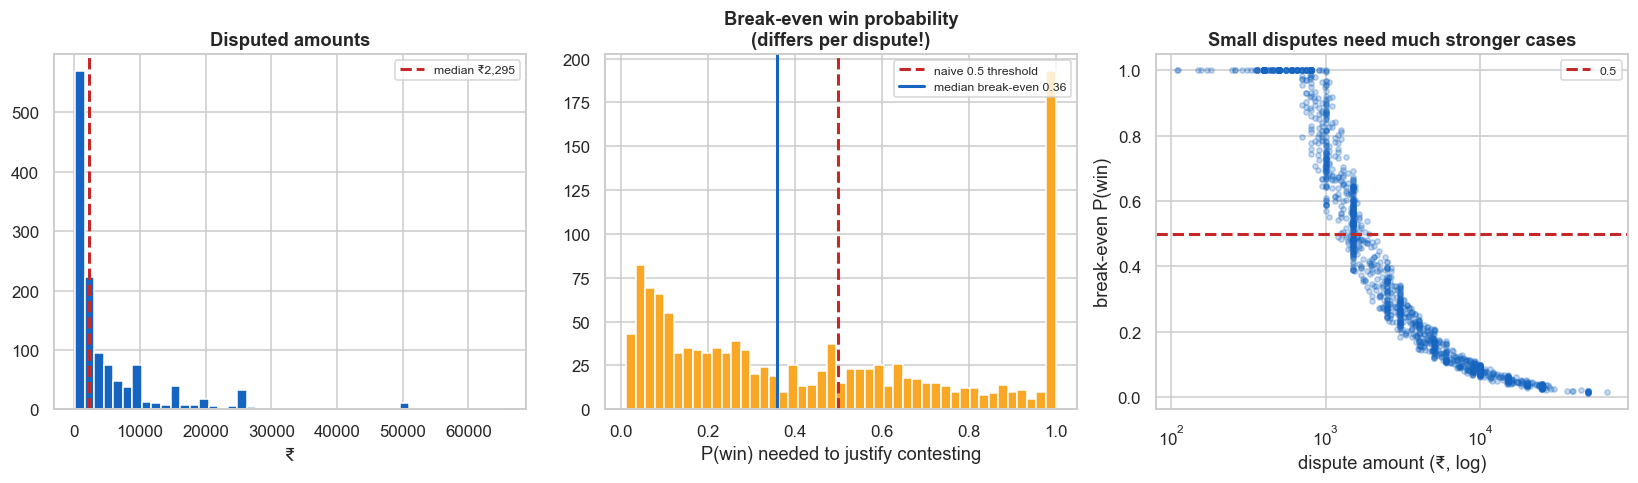

Median break-even probability : 35.9%
Disputes needing >50% to justify contesting: 40.1%


In [57]:
econ = model_df.copy()
econ['total_cost']    = econ.contest_fee + econ.operational_review_cost
econ['breakeven_p']   = econ.total_cost / econ.dispute_amount
econ['breakeven_p']   = econ.breakeven_p.clip(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(econ.dispute_amount, bins=45, color=COL_PRIMARY, edgecolor='white')
axes[0].axvline(econ.dispute_amount.median(), color=COL_LOST, ls='--', lw=2,
                label=f'median ₹{econ.dispute_amount.median():,.0f}')
axes[0].set_title('Disputed amounts', fontweight='bold')
axes[0].set_xlabel('₹'); axes[0].legend(fontsize=8)

axes[1].hist(econ.breakeven_p, bins=45, color=COL_ACCEPTED, edgecolor='white')
axes[1].axvline(0.5, color=COL_LOST, ls='--', lw=2, label='naive 0.5 threshold')
axes[1].axvline(econ.breakeven_p.median(), color=COL_PRIMARY, ls='-', lw=2,
                label=f'median break-even {econ.breakeven_p.median():.2f}')
axes[1].set_title('Break-even win probability\n(differs per dispute!)', fontweight='bold')
axes[1].set_xlabel('P(win) needed to justify contesting'); axes[1].legend(fontsize=8)

axes[2].scatter(econ.dispute_amount, econ.breakeven_p, alpha=0.25,
                color=COL_PRIMARY, s=12)
axes[2].axhline(0.5, color=COL_LOST, ls='--', lw=2, label='0.5')
axes[2].set_xscale('log')
axes[2].set_title('Small disputes need much stronger cases', fontweight='bold')
axes[2].set_xlabel('dispute amount (₹, log)'); axes[2].set_ylabel('break-even P(win)')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f'Median break-even probability : {econ.breakeven_p.median():.1%}')
print(f'Disputes needing >50% to justify contesting: {(econ.breakeven_p > 0.5).mean():.1%}')

## 11.3 The baselines our model must beat

Two naive strategies. If our model cannot beat both **in rupees**, it adds no business value regardless of its AUC.

- **Always contest:** fight everything. Wins the winnable, wastes fees on the hopeless.
- **Always accept:** never fight. Zero fees, zero recoveries.

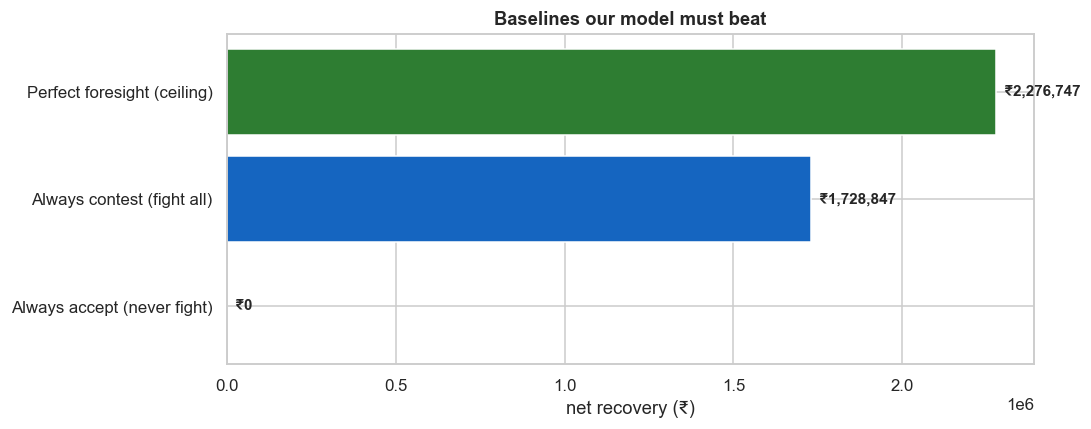

,strategy,net_INR_display
0,Always accept (never fight),₹0
1,Always contest (fight all),"₹1,728,847"
2,Perfect foresight (ceiling),"₹2,276,747"



Headroom available to the model: ₹547,900 above the best naive strategy.


In [58]:
def evaluate(decisions, actual_won, amount, cost):
    """Net rupees for a set of contest (1) / accept (0) decisions."""
    net = np.where(decisions == 1, np.where(actual_won == 1, amount - cost, -cost), 0.0)
    return net.sum()

amt  = econ.dispute_amount.values
cost = econ.total_cost.values
won  = econ.won.values

always_contest = evaluate(np.ones(len(econ)),  won, amt, cost)
always_accept  = evaluate(np.zeros(len(econ)), won, amt, cost)
perfect        = evaluate(won,                 won, amt, cost)   # upper bound

bl = pd.DataFrame([
    {'strategy': 'Always accept (never fight)', 'net_INR': always_accept},
    {'strategy': 'Always contest (fight all)',  'net_INR': always_contest},
    {'strategy': 'Perfect foresight (ceiling)', 'net_INR': perfect},
])
bl['net_INR_display'] = bl.net_INR.apply(lambda v: f'₹{v:,.0f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(bl.strategy, bl.net_INR,
        color=[COL_ACCEPTED, COL_PRIMARY, COL_WON])
ax.set_xlabel('net recovery (₹)')
ax.set_title('Baselines our model must beat', fontweight='bold')
for i, v in enumerate(bl.net_INR):
    ax.text(v, i, f'  ₹{v:,.0f}', va='center', fontweight='bold')
plt.tight_layout(); plt.show()

display(bl[['strategy', 'net_INR_display']])
print(f'\nHeadroom available to the model: '
      f'₹{perfect - always_contest:,.0f} above the best naive strategy.')

**This chart is the single most persuasive artefact in the project.** "Our system recovers ₹X more than fighting everything and ₹Y more than accepting everything" is a sentence any non-technical reviewer understands immediately — and it is the sentence almost no competing submission will be able to make.

---
# 12. Subgroup sizes — where will the model be unreliable?

A model trained on 1,100 rows will not perform equally across all business types. Knowing *where* it is weak is part of being honest about it.

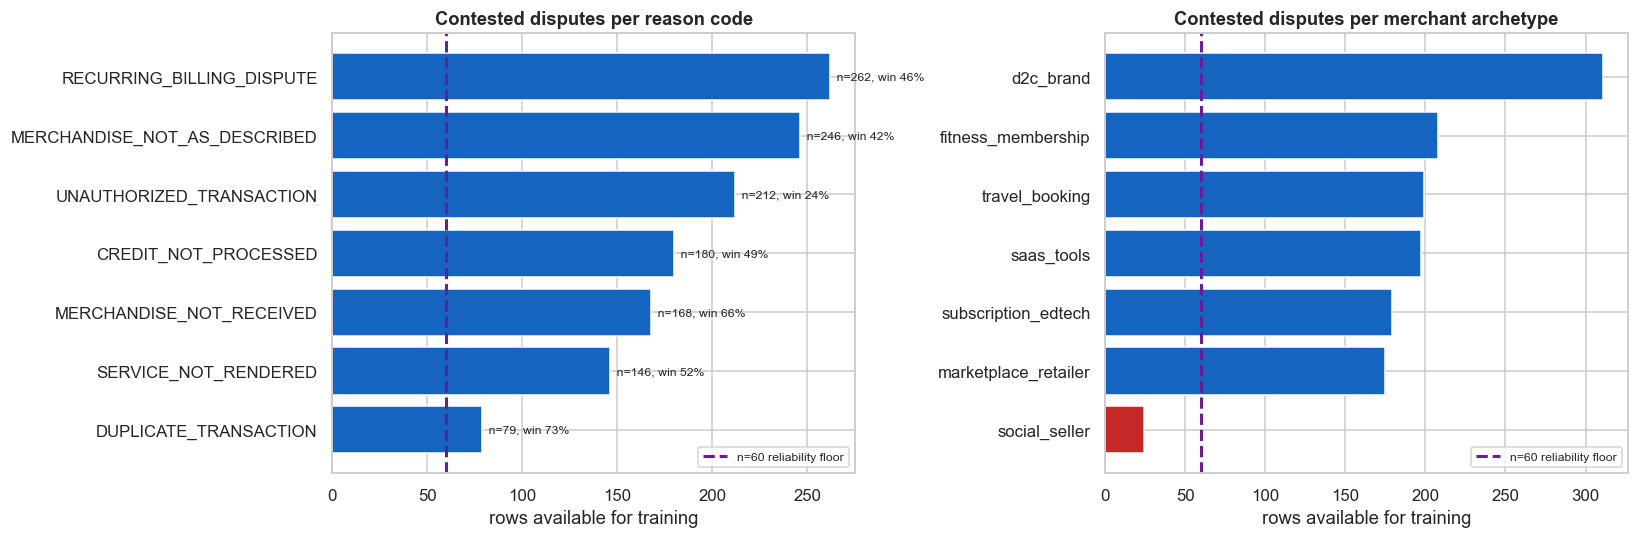

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sub = (model_df.groupby('reason_code')
       .agg(n=('won', 'size'), win_rate=('won', 'mean'))
       .sort_values('n'))
axes[0].barh(sub.index, sub.n, color=[COL_LOST if n < 60 else COL_PRIMARY for n in sub.n])
axes[0].axvline(60, color=COL_BENCH, ls='--', lw=2, label='n=60 reliability floor')
axes[0].set_title('Contested disputes per reason code', fontweight='bold')
axes[0].set_xlabel('rows available for training'); axes[0].legend(fontsize=8)
for i, (n, w) in enumerate(zip(sub.n, sub.win_rate)):
    axes[0].text(n, i, f'  n={n}, win {w:.0%}', va='center', fontsize=8)

sub2 = (model_df.groupby('archetype')
        .agg(n=('won', 'size'), win_rate=('won', 'mean'))
        .sort_values('n'))
axes[1].barh(sub2.index, sub2.n,
             color=[COL_LOST if n < 60 else COL_PRIMARY for n in sub2.n])
axes[1].axvline(60, color=COL_BENCH, ls='--', lw=2, label='n=60 reliability floor')
axes[1].set_title('Contested disputes per merchant archetype', fontweight='bold')
axes[1].set_xlabel('rows available for training'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

thin = sub[sub.n < 60]
if len(thin):
    print('LOW-CONFIDENCE SUBGROUPS (report wider error bars for these):')
    display(thin)

### 🎯 ML decision #4 — evaluation strategy

Given the sample size:

- Use **stratified 5-fold cross-validation**, not a single train/test split. One split on ~1,100 rows produces a test set of ~220, where a handful of cases can swing a metric by several points.
- Report **mean ± standard deviation** across folds, never a bare point estimate.
- For `DUPLICATE_TRANSACTION` (n≈48), report results with an explicit caveat — that subgroup is too small for confident claims.

---
# 13. Demo merchants — the dashboard walkthrough

Nine merchants are designated for the dashboard demo, one per archetype. `demo_priority` ranks them by how well they illustrate the system — a good demo needs both volume and contrast in evidence quality.

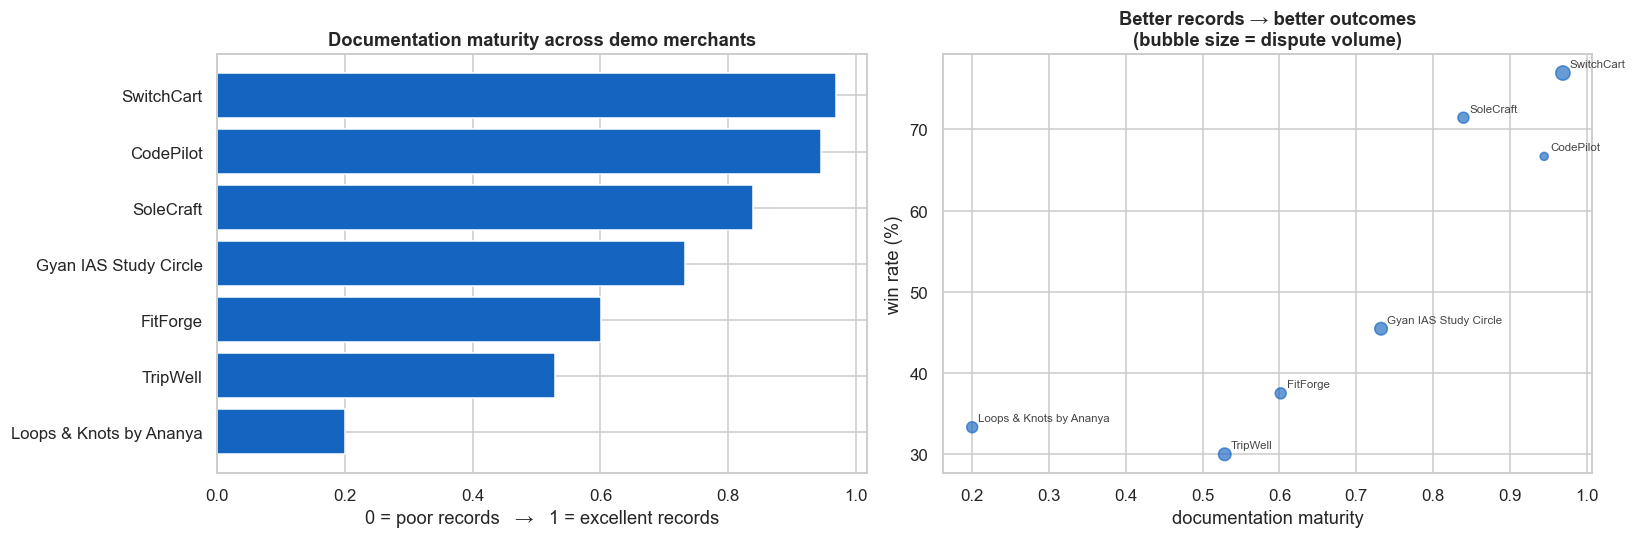

,demo_priority,merchant_name,merchant_archetype,documentation_maturity,dispute_count,contested,win_rate
0,1,SwitchCart,marketplace_retailer,0.969,22,13,0.769
1,2,TripWell,travel_booking,0.529,17,10,0.300
2,3,Gyan IAS Study Circle,subscription_edtech,0.732,17,11,0.455
3,4,SoleCraft,d2c_brand,0.839,13,7,0.714
4,5,CodePilot,saas_tools,0.945,7,6,0.667
5,6,FitForge,fitness_membership,0.602,13,8,0.375
6,7,Loops & Knots by Ananya,social_seller,0.200,13,6,0.333


In [60]:
dm = demo.merge(
    model_df.groupby('merchant_id').agg(
        contested=('won', 'size'), win_rate=('won', 'mean')).reset_index(),
    on='merchant_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

d_sorted = dm.sort_values('documentation_maturity')
axes[0].barh(d_sorted.merchant_name, d_sorted.documentation_maturity,
             color=COL_PRIMARY)
axes[0].set_title('Documentation maturity across demo merchants', fontweight='bold')
axes[0].set_xlabel('0 = poor records   →   1 = excellent records')

axes[1].scatter(dm.documentation_maturity, dm.win_rate * 100,
                s=dm.dispute_count * 4, alpha=0.65, color=COL_PRIMARY)
for _, r in dm.iterrows():
    if pd.notna(r.win_rate):
        axes[1].annotate(r.merchant_name,
                         (r.documentation_maturity, r.win_rate * 100),
                         fontsize=7.5, alpha=0.85,
                         xytext=(4, 4), textcoords='offset points')
axes[1].set_xlabel('documentation maturity'); axes[1].set_ylabel('win rate (%)')
axes[1].set_title('Better records → better outcomes\n(bubble size = dispute volume)',
                  fontweight='bold')

plt.tight_layout(); plt.show()

display(dm[['demo_priority', 'merchant_name', 'merchant_archetype',
            'documentation_maturity', 'dispute_count', 'contested', 'win_rate']]
        .sort_values('demo_priority').round(3).reset_index(drop=True))

**For the pitch video:** lead with the highest and lowest maturity merchants. The contrast between a merchant with strong records winning most disputes, and one with poor records where the system correctly recommends *accepting*, is the clearest possible demonstration that the tool exercises judgement rather than just fighting everything.

---
# 14. Export for the ML notebook

We save the prepared modelling table plus a documented feature manifest, so the ML notebook starts from a clean, reproducible foundation.

In [61]:
import json, os

DROP_LEAKAGE = [
    'dispute_outcome', 'merchant_action', 'resolution_date',   # target / post-decision
    'dispute_id', 'transaction_id', 'merchant_id', 'customer_id',  # identifiers
    'reason_description',                                       # free text duplicate
    'dispute_created_at', 'respond_by',                         # raw timestamps (derived above)
]
DROP_REDUNDANT = ['amount', 'operational_review_cost', 'n_available', 'evidence_completeness']

feature_cols = [c for c in model_df.columns
                if c not in DROP_LEAKAGE + DROP_REDUNDANT + ['won']]

os.makedirs('outputs', exist_ok=True)
model_df.to_csv('outputs/model_table_contested.csv', index=False)
df.to_csv('outputs/dispute_master_all.csv', index=False)

manifest = {
    'target': 'won  (1 = merchant won, 0 = merchant lost)',
    'population': 'contested disputes only — accepted disputes have no bank verdict',
    'n_rows': int(len(model_df)),
    'positive_rate': round(float(model_df.won.mean()), 4),
    'recommended_primary_model': 'LogisticRegression (scaled, L2)',
    'recommended_benchmark_model': 'RandomForestClassifier',
    'class_balancing_required': False,
    'evaluation': 'StratifiedKFold(5), report mean ± std; calibrate before decision layer',
    'dropped_leakage': DROP_LEAKAGE,
    'dropped_redundant': DROP_REDUNDANT,
    'features': feature_cols,
    'cost_matrix': {
        'contest_and_win':  'dispute_amount - contest_fee - operational_review_cost',
        'contest_and_lose': '-(contest_fee + operational_review_cost)',
        'accept':           '0',
        'breakeven_p':      '(contest_fee + operational_review_cost) / dispute_amount',
    },
    'baselines_INR': {
        'always_accept':  float(always_accept),
        'always_contest': float(always_contest),
        'perfect':        float(perfect),
    },
}

with open('outputs/feature_manifest.json', 'w') as fh:
    json.dump(manifest, fh, indent=2)

print(f'Saved outputs/model_table_contested.csv  ({len(model_df):,} rows)')
print(f'Saved outputs/dispute_master_all.csv     ({len(df):,} rows)')
print(f'Saved outputs/feature_manifest.json      ({len(feature_cols)} features)')

Saved outputs/model_table_contested.csv  (1,293 rows)
Saved outputs/dispute_master_all.csv     (1,953 rows)
Saved outputs/feature_manifest.json      (35 features)


---
# 15. Summary — what we decided and why

## Data quality
- ✅ All primary keys unique; zero foreign-key orphans
- ✅ Business rules hold: accepted disputes carry no fees and no verdict
- ✅ Temporal integrity: no transaction or evidence record post-dates its dispute
- ✅ No leakage: strongest single feature reaches ~0.36 correlation, far below the 0.55 threshold

## Scope
- **Card disputes only.** UPI chargebacks are auto-resolved by NPCI via settlement reconciliation, so no evidence is ever submitted and there is no decision for the system to make.

## The target
- Predict **`won` / `lost`, on contested disputes only** (n ≈ 1,100). Accepted disputes have no verdict and cannot be labelled.
- We deliberately do **not** learn a contest/accept label — that decision is *computed* from predicted probability and the cost matrix.

## Algorithm decisions

| # | Decision | Evidence |
|---|---|---|
| 1 | **No class balancing** | Target is 46/54 — near balanced |
| 2 | **Primary: Logistic Regression; benchmark: Random Forest** | LR ≈ RF > GBM in CV; relationships largely linear; only ~25 rows per feature |
| 3 | **Drop 4 redundant features** | Four pairs at \|r\| > 0.8 |
| 4 | **Stratified 5-fold CV, report mean ± std** | ~1,100 rows makes a single split unstable |
| 5 | **Calibrate before the decision layer** | Probabilities are multiplied by rupee amounts — they must be *true*, not merely well-ranked |

## Known limitations, stated openly
1. **Dispute rate (~1.8%) exceeds the industry benchmark and Visa's VAMP threshold** — a deliberate trade of population realism for a usable sample size.
2. **Synthetic data calibrated to global benchmarks** — no India-specific chargeback statistics are published.
3. **Win outcomes are modelled, not observed** — drawn from a documented latent model, not real bank decisions.
4. **Merchant-scoped customer identity** — cross-merchant abuse patterns are invisible by design, matching a real single-merchant integration.
5. **`DUPLICATE_TRANSACTION` has only ~48 contested rows** — treat its metrics as indicative.

---

## Next: the ML notebook

1. Load `outputs/model_table_contested.csv` and `feature_manifest.json`
2. Train logistic regression and random forest; compare with stratified CV
3. Calibrate the chosen model; verify with a reliability curve
4. Compute the per-dispute break-even threshold and derive contest/accept decisions
5. Report precision, recall, **and net rupees recovered** against both naive baselines
6. Add SHAP explanations for the merchant-facing "why" narrative